# 🔴 Crime Data Warehouse — Full Pipeline (2022–2024)

**Project:** Crime Data Warehouse · ETL · Star Schema · SQL Analytics · Visualization · Association Rules · ML Prediction · Victim Risk Profiling · NL Query Interface · Real-Time Alert Simulation · Data Quality Dashboard

```
CSV File
  └─► ETL (Extract → Transform → Load)
        └─► SQLite Data Warehouse (Star Schema)
              ├─► SQL Analytics Queries
              ├─► Visualization Dashboard
              ├─► Association Rule Mining
              ├─► Regression Prediction (R² improved via GBM)
              ├─► Victim Risk Profiling Engine
              ├─► Data Quality & Lineage Dashboard
              ├─► Real-Time Crime Alert Simulation
              └─► Natural Language Query Interface (AI-Powered)
```

**Dataset columns:** Report Number, Date Reported, Date of Occurrence, Time of Occurrence, City, Crime Description, Victim Age, Victim Gender, Weapon Used, Crime Domain, Police Deployed, Case Closed, Date Case Closed

---

## 📦 STEP 0 — Import Libraries

In [10]:
%pip install ipywidgets

import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import re
import os
import json as _json
from itertools import combinations
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error, r2_score,
    classification_report, accuracy_score, confusion_matrix
)
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

print('✅ All libraries loaded successfully.')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=16667) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
✅ All libraries loaded successfully.


---
## 📥 STEP 1 — Load Dataset

**Set the path to your CSV file in the cell below.**  
The dataset should have these columns:  
`Report Number, Date Reported, Date of Occurrence, Time of Occurrence, City, Crime Description, Victim Age, Victim Gender, Weapon Used, Crime Domain, Police Deployed, Case Closed, Date Case Closed`

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# ✏️  CHANGE THIS PATH to your CSV file
# ─────────────────────────────────────────────────────────────────────────────
CSV_PATH = '/Users/sanhithamadupalli/Downloads/crime_dataset_india.csv'
DB_PATH  = 'crime_warehouse.db'

# Load
try:
    df_raw = pd.read_csv(CSV_PATH)
    print(f'✅ Dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
    display(df_raw.head(5))
except FileNotFoundError:
    raise FileNotFoundError(
        f'❌ File not found: "{CSV_PATH}"\n'
        'Please update the CSV_PATH variable above with the correct path.'
    )

✅ Dataset loaded: 40,160 rows × 14 columns


,Report Number,Date Reported,Date of Occurrence,Time of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,Case Closed,Date Case Closed
0,1,02-01-2020 00:00,01-01-2020 00:00,01-01-2020 01:11,Ahmedabad,576,IDENTITY THEFT,16,M,Blunt Object,Violent Crime,13,No,NaN
1,2,01-01-2020 19:00,01-01-2020 01:00,01-01-2020 06:26,Chennai,128,HOMICIDE,37,M,Poison,Other Crime,9,No,NaN
2,3,02-01-2020 05:00,01-01-2020 02:00,01-01-2020 14:30,Ludhiana,271,KIDNAPPING,48,F,Blunt Object,Other Crime,15,No,NaN
3,4,01-01-2020 05:00,01-01-2020 03:00,01-01-2020 14:46,Pune,170,BURGLARY,49,F,Firearm,Other Crime,1,Yes,29-04-2020 05:00
4,5,01-01-2020 21:00,01-01-2020 04:00,01-01-2020 16:51,Pune,421,VANDALISM,30,F,Other,Other Crime,18,Yes,08-01-2020 21:00


---
## 🔄 STEP 2 — ETL: Extract, Transform, Load

We clean the raw data before loading it into the warehouse.

In [12]:
print('=' * 60)
print('📥 EXTRACT')
print('=' * 60)
df = df_raw.copy()
print(f'  Rows loaded     : {len(df):,}')
print(f'  Columns         : {list(df.columns)}')
print(f'  Missing values  :\n{df.isnull().sum()[df.isnull().sum() > 0]}')

print('\n' + '=' * 60)
print('🔄 TRANSFORM')
print('=' * 60)

# ── 1. Remove duplicates on Report Number
before = len(df)
df.drop_duplicates(subset='Report Number', inplace=True)
print(f'  Duplicates removed          : {before - len(df)}')

# ── 2. Parse dates
for col in ['Date Reported', 'Date of Occurrence', 'Date Case Closed']:
    df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')

# ── 3. Derive date parts from 'Date of Occurrence'
df['year']    = df['Date of Occurrence'].dt.year
df['month']   = df['Date of Occurrence'].dt.month
df['quarter'] = df['Date of Occurrence'].dt.quarter
df['day_of_week'] = df['Date of Occurrence'].dt.day_name()

# ── 4. Parse hour from Time of Occurrence
df['hour'] = pd.to_numeric(
    df['Time of Occurrence'].astype(str).str.extract(r'(\d{1,2}):', expand=False),
    errors='coerce'
)
df['time_of_day'] = pd.cut(
    df['hour'], bins=[-1, 5, 11, 17, 20, 24],
    labels=['Night', 'Morning', 'Afternoon', 'Evening', 'Night-Late']
)

# ── 5. Fill nulls
df['Weapon Used']  = df['Weapon Used'].fillna('Unknown')
df['Victim Gender'] = df['Victim Gender'].fillna('Unknown')
df['Case Closed']  = df['Case Closed'].fillna('No')

# ── 6. Standardize text columns
text_cols = ['City', 'Crime Description', 'Victim Gender', 'Weapon Used', 'Crime Domain', 'Case Closed']
for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

# ── 7. Validate numeric ranges
df = df[(df['Victim Age'] > 0) & (df['Victim Age'] <= 100)]
df = df[df['Police Deployed'] >= 0]
df.dropna(subset=['year', 'month'], inplace=True)
df['year']  = df['year'].astype(int)
df['month'] = df['month'].astype(int)

# ── 8. Age group
df['age_group'] = pd.cut(
    df['Victim Age'],
    bins=[0, 17, 29, 44, 59, 100],
    labels=['Minor', 'Young Adult', 'Adult', 'Middle-Aged', 'Senior']
)

# ── 9. Days to close case
df['days_to_close'] = (df['Date Case Closed'] - df['Date Reported']).dt.days
df['days_to_close'] = df['days_to_close'].clip(lower=0)

print(f'  Clean rows remaining        : {len(df):,}')
print(f'  Years in dataset            : {sorted(df["year"].unique())}')
print(f'  Unique cities               : {df["City"].nunique()}')
print(f'  Unique crime types          : {df["Crime Description"].nunique()}')
print(f'  Crime domains               : {df["Crime Domain"].unique().tolist()}')
print()
display(df[['Report Number','City','Crime Description','Victim Age','age_group',
            'Weapon Used','Case Closed','year','month','quarter','hour','time_of_day']].head(5))

📥 EXTRACT
  Rows loaded     : 40,160
  Columns         : ['Report Number', 'Date Reported', 'Date of Occurrence', 'Time of Occurrence', 'City', 'Crime Code', 'Crime Description', 'Victim Age', 'Victim Gender', 'Weapon Used', 'Crime Domain', 'Police Deployed', 'Case Closed', 'Date Case Closed']
  Missing values  :
Weapon Used          5790
Date Case Closed    20098
dtype: int64

🔄 TRANSFORM
  Duplicates removed          : 0
  Clean rows remaining        : 15,840
  Years in dataset            : [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
  Unique cities               : 29
  Unique crime types          : 21
  Crime domains               : ['Violent Crime', 'Other Crime', 'Fire Accident', 'Traffic Fatality']



,Report Number,City,Crime Description,Victim Age,age_group,Weapon Used,Case Closed,year,month,quarter,hour,time_of_day
0,1,Ahmedabad,Identity Theft,16,Minor,Blunt Object,No,2020,1,1.0,1,Night
1,2,Chennai,Homicide,37,Adult,Poison,No,2020,1,1.0,6,Morning
2,3,Ludhiana,Kidnapping,48,Middle-Aged,Blunt Object,No,2020,1,1.0,14,Afternoon
3,4,Pune,Burglary,49,Middle-Aged,Firearm,Yes,2020,1,1.0,14,Afternoon
4,5,Pune,Vandalism,30,Adult,Other,Yes,2020,1,1.0,16,Afternoon


---
## 🗄️ STEP 3 — Star Schema Data Warehouse

```
                  ┌──────────────┐
                  │  Crime_Dim   │
                  │ crime_dim_id │
                  │ crime_type   │
                  │ crime_domain │
                  └──────┬───────┘
                         │
┌─────────────┐   ┌──────▼────────┐   ┌──────────────┐
│ Location_Dim│───│  Crime_Fact   │───│  Date_Dim    │
│ city        │   │ (fact_id PK)  │   │ year, month  │
└─────────────┘   │ cases = 1     │   │ quarter      │
                  │ police_deployed│  │ day_of_week  │
┌─────────────┐   │ days_to_close │   └──────────────┘
│ Person_Dim  │───│               │
│ age, gender │   └──────┬────────┘
│ age_group   │          │
└─────────────┘   ┌──────┴────────┐   ┌──────────────┐
                  │  Weapon_Dim   │   │  Status_Dim  │
                  │ weapon        │   │ case_closed  │
                  └───────────────┘   └──────────────┘
```

In [13]:
conn = sqlite3.connect(DB_PATH)
cur  = conn.cursor()

# ── Drop and recreate all tables ──────────────────────────────
cur.executescript('''
    DROP TABLE IF EXISTS Crime_Fact;
    DROP TABLE IF EXISTS Crime_Dim;
    DROP TABLE IF EXISTS Location_Dim;
    DROP TABLE IF EXISTS Date_Dim;
    DROP TABLE IF EXISTS Person_Dim;
    DROP TABLE IF EXISTS Weapon_Dim;
    DROP TABLE IF EXISTS Status_Dim;

    CREATE TABLE Crime_Dim (
        crime_dim_id  INTEGER PRIMARY KEY,
        crime_type    TEXT NOT NULL,
        crime_domain  TEXT NOT NULL
    );

    CREATE TABLE Location_Dim (
        location_dim_id INTEGER PRIMARY KEY,
        city            TEXT NOT NULL
    );

    CREATE TABLE Date_Dim (
        date_dim_id  INTEGER PRIMARY KEY,
        year         INTEGER,
        month        INTEGER,
        quarter      INTEGER,
        day_of_week  TEXT,
        time_of_day  TEXT
    );

    CREATE TABLE Person_Dim (
        person_dim_id INTEGER PRIMARY KEY,
        age           INTEGER,
        gender        TEXT,
        age_group     TEXT
    );

    CREATE TABLE Weapon_Dim (
        weapon_dim_id INTEGER PRIMARY KEY,
        weapon        TEXT NOT NULL
    );

    CREATE TABLE Status_Dim (
        status_dim_id INTEGER PRIMARY KEY,
        case_closed   TEXT NOT NULL
    );

    CREATE TABLE Crime_Fact (
        fact_id          INTEGER PRIMARY KEY AUTOINCREMENT,
        report_number    INTEGER,
        crime_dim_id     INTEGER REFERENCES Crime_Dim(crime_dim_id),
        location_dim_id  INTEGER REFERENCES Location_Dim(location_dim_id),
        date_dim_id      INTEGER REFERENCES Date_Dim(date_dim_id),
        person_dim_id    INTEGER REFERENCES Person_Dim(person_dim_id),
        weapon_dim_id    INTEGER REFERENCES Weapon_Dim(weapon_dim_id),
        status_dim_id    INTEGER REFERENCES Status_Dim(status_dim_id),
        police_deployed  INTEGER,
        days_to_close    REAL,
        cases            INTEGER DEFAULT 1
    );
''')

# ── Build Dimension Tables ─────────────────────────────────────

# Crime_Dim
crime_dim = (
    df[['Crime Description','Crime Domain']]
    .drop_duplicates()
    .reset_index(drop=True)
    .rename(columns={'Crime Description':'crime_type','Crime Domain':'crime_domain'})
)
crime_dim.insert(0, 'crime_dim_id', range(1, len(crime_dim)+1))
crime_dim.to_sql('Crime_Dim', conn, if_exists='append', index=False)

# Location_Dim
location_dim = (
    df[['City']].drop_duplicates().reset_index(drop=True)
    .rename(columns={'City':'city'})
)
location_dim.insert(0, 'location_dim_id', range(1, len(location_dim)+1))
location_dim.to_sql('Location_Dim', conn, if_exists='append', index=False)

# Date_Dim
date_dim = (
    df[['year','month','quarter','day_of_week','time_of_day']]
    .drop_duplicates().reset_index(drop=True)
)
date_dim['time_of_day'] = date_dim['time_of_day'].astype(str)
date_dim.insert(0, 'date_dim_id', range(1, len(date_dim)+1))
date_dim.to_sql('Date_Dim', conn, if_exists='append', index=False)

# Person_Dim
person_dim = (
    df[['Victim Age','Victim Gender','age_group']]
    .drop_duplicates().reset_index(drop=True)
    .rename(columns={'Victim Age':'age','Victim Gender':'gender'})
)
person_dim['age_group'] = person_dim['age_group'].astype(str)
person_dim.insert(0, 'person_dim_id', range(1, len(person_dim)+1))
person_dim.to_sql('Person_Dim', conn, if_exists='append', index=False)

# Weapon_Dim
weapon_dim = (
    df[['Weapon Used']].drop_duplicates().reset_index(drop=True)
    .rename(columns={'Weapon Used':'weapon'})
)
weapon_dim.insert(0, 'weapon_dim_id', range(1, len(weapon_dim)+1))
weapon_dim.to_sql('Weapon_Dim', conn, if_exists='append', index=False)

# Status_Dim
status_dim = (
    df[['Case Closed']].drop_duplicates().reset_index(drop=True)
    .rename(columns={'Case Closed':'case_closed'})
)
status_dim.insert(0, 'status_dim_id', range(1, len(status_dim)+1))
status_dim.to_sql('Status_Dim', conn, if_exists='append', index=False)

print('✅ Dimension tables created:')
for name, tbl in [('Crime_Dim', crime_dim), ('Location_Dim', location_dim),
                  ('Date_Dim', date_dim), ('Person_Dim', person_dim),
                  ('Weapon_Dim', weapon_dim), ('Status_Dim', status_dim)]:
    print(f'   {name:<20} {len(tbl):>5} rows')

✅ Dimension tables created:
   Crime_Dim               21 rows
   Location_Dim            29 rows
   Date_Dim              2084 rows
   Person_Dim             210 rows
   Weapon_Dim               7 rows
   Status_Dim               2 rows


In [14]:
# ── Build Fact Table ──────────────────────────────────────────
print('🔨 Building Crime_Fact table...')

# Merge all FK lookups in one shot
fact = df.copy()
fact = fact.merge(crime_dim,    left_on=['Crime Description','Crime Domain'],  right_on=['crime_type','crime_domain'],   how='left')
fact = fact.merge(location_dim, left_on='City',                                right_on='city',                          how='left')
fact = fact.merge(date_dim,     on=['year','month','quarter','day_of_week'],    how='left')
fact['age_group_str'] = fact['age_group'].astype(str)
person_dim['age_group_str'] = person_dim['age_group'].astype(str)
fact = fact.merge(person_dim,   left_on=['Victim Age','Victim Gender','age_group_str'],
                                right_on=['age','gender','age_group_str'],      how='left')
fact = fact.merge(weapon_dim,   left_on='Weapon Used',                         right_on='weapon',                        how='left')
fact = fact.merge(status_dim,   left_on='Case Closed',                         right_on='case_closed',                   how='left')

fact_load = fact[[
    'Report Number', 'crime_dim_id', 'location_dim_id', 'date_dim_id',
    'person_dim_id', 'weapon_dim_id', 'status_dim_id',
    'Police Deployed', 'days_to_close'
]].copy()
fact_load.columns = [
    'report_number', 'crime_dim_id', 'location_dim_id', 'date_dim_id',
    'person_dim_id', 'weapon_dim_id', 'status_dim_id',
    'police_deployed', 'days_to_close'
]
fact_load['cases'] = 1

# Drop rows with missing FK
fact_load.dropna(subset=['crime_dim_id','location_dim_id','date_dim_id',
                          'person_dim_id','weapon_dim_id','status_dim_id'], inplace=True)
fact_load.to_sql('Crime_Fact', conn, if_exists='append', index=False)
conn.commit()

total_facts = pd.read_sql_query('SELECT COUNT(*) AS n FROM Crime_Fact', conn)['n'][0]
print(f'✅ Crime_Fact loaded: {total_facts:,} rows')
print('\n📊 Warehouse schema summary:')
for tbl in ['Crime_Dim','Location_Dim','Date_Dim','Person_Dim','Weapon_Dim','Status_Dim','Crime_Fact']:
    cnt = pd.read_sql_query(f'SELECT COUNT(*) AS n FROM {tbl}', conn)['n'][0]
    print(f'   {tbl:<20} {cnt:>6} rows')

🔨 Building Crime_Fact table...
✅ Crime_Fact loaded: 78,792 rows

📊 Warehouse schema summary:
   Crime_Dim                21 rows
   Location_Dim             29 rows
   Date_Dim               2084 rows
   Person_Dim              210 rows
   Weapon_Dim                7 rows
   Status_Dim                2 rows
   Crime_Fact            78792 rows


---
## 📊 STEP 4 — SQL Analytics Queries

In [15]:
queries = {
    'Q1 — Most Common Crime Types': '''
        SELECT cd.crime_type, cd.crime_domain, SUM(cf.cases) AS total_cases
        FROM Crime_Fact cf
        JOIN Crime_Dim cd ON cf.crime_dim_id = cd.crime_dim_id
        GROUP BY cd.crime_type, cd.crime_domain
        ORDER BY total_cases DESC
        LIMIT 15
    ''',
    'Q2 — Crime per City': '''
        SELECT ld.city, SUM(cf.cases) AS total_cases,
               ROUND(AVG(cf.police_deployed),1) AS avg_police
        FROM Crime_Fact cf
        JOIN Location_Dim ld ON cf.location_dim_id = ld.location_dim_id
        GROUP BY ld.city
        ORDER BY total_cases DESC
    ''',
    'Q3 — Annual Crime Trend': '''
        SELECT dd.year, SUM(cf.cases) AS total_cases,
               ROUND(AVG(cf.police_deployed),1) AS avg_police
        FROM Crime_Fact cf
        JOIN Date_Dim dd ON cf.date_dim_id = dd.date_dim_id
        GROUP BY dd.year ORDER BY dd.year
    ''',
    'Q4 — Quarterly Breakdown': '''
        SELECT dd.year, dd.quarter, SUM(cf.cases) AS total_cases
        FROM Crime_Fact cf
        JOIN Date_Dim dd ON cf.date_dim_id = dd.date_dim_id
        GROUP BY dd.year, dd.quarter ORDER BY dd.year, dd.quarter
    ''',
    'Q5 — Weapon Usage': '''
        SELECT wd.weapon, COUNT(*) AS incidents
        FROM Crime_Fact cf
        JOIN Weapon_Dim wd ON cf.weapon_dim_id = wd.weapon_dim_id
        GROUP BY wd.weapon ORDER BY incidents DESC
    ''',
    'Q6 — Case Closure Rate by City': '''
        SELECT ld.city,
               SUM(cf.cases) AS total,
               SUM(CASE WHEN sd.case_closed = 'Yes' THEN 1 ELSE 0 END) AS closed,
               ROUND(100.0 * SUM(CASE WHEN sd.case_closed = 'Yes' THEN 1 ELSE 0 END)
                     / SUM(cf.cases), 1) AS closure_pct
        FROM Crime_Fact cf
        JOIN Location_Dim ld ON cf.location_dim_id = ld.location_dim_id
        JOIN Status_Dim sd   ON cf.status_dim_id   = sd.status_dim_id
        GROUP BY ld.city ORDER BY closure_pct DESC
    ''',
    'Q7 — Crime by Victim Age Group': '''
        SELECT pd.age_group, SUM(cf.cases) AS total_cases
        FROM Crime_Fact cf
        JOIN Person_Dim pd ON cf.person_dim_id = pd.person_dim_id
        GROUP BY pd.age_group ORDER BY total_cases DESC
    ''',
    'Q8 — Crime by Time of Day': '''
        SELECT dd.time_of_day, SUM(cf.cases) AS total_cases
        FROM Crime_Fact cf
        JOIN Date_Dim dd ON cf.date_dim_id = dd.date_dim_id
        GROUP BY dd.time_of_day ORDER BY total_cases DESC
    ''',
    'Q9 — Avg Days to Close by Crime Domain': '''
        SELECT cd.crime_domain,
               ROUND(AVG(cf.days_to_close),1) AS avg_days_to_close,
               COUNT(*) AS total_cases
        FROM Crime_Fact cf
        JOIN Crime_Dim cd ON cf.crime_dim_id = cd.crime_dim_id
        WHERE cf.days_to_close IS NOT NULL
        GROUP BY cd.crime_domain ORDER BY avg_days_to_close
    ''',
    'Q10 — Crime × Weapon Cross-Tab': '''
        SELECT cd.crime_type, wd.weapon, COUNT(*) AS count
        FROM Crime_Fact cf
        JOIN Crime_Dim  cd ON cf.crime_dim_id  = cd.crime_dim_id
        JOIN Weapon_Dim wd ON cf.weapon_dim_id = wd.weapon_dim_id
        GROUP BY cd.crime_type, wd.weapon
        ORDER BY count DESC LIMIT 20
    '''
}

results = {}
for title, sql in queries.items():
    r = pd.read_sql_query(sql, conn)
    results[title] = r
    print(f'\n{'='*60}')
    print(f'  {title}')
    print(f'{'='*60}')
    display(r)


  Q1 — Most Common Crime Types


,crime_type,crime_domain,total_cases
0,Burglary,Other Crime,3917
1,Identity Theft,Violent Crime,3902
2,Fraud,Other Crime,3890
3,Domestic Violence,Violent Crime,3829
4,Vandalism,Other Crime,3818
5,Firearm Offense,Fire Accident,3807
6,Homicide,Other Crime,3786
7,Robbery,Violent Crime,3777
8,Cybercrime,Other Crime,3765
9,Kidnapping,Other Crime,3761



  Q2 — Crime per City


,city,total_cases,avg_police
0,Delhi,10442,10.0
1,Mumbai,8592,10.1
2,Bangalore,7113,10.0
3,Hyderabad,5779,9.9
4,Kolkata,5073,10.0
5,Chennai,4902,10.3
6,Pune,4474,10.0
7,Ahmedabad,3420,10.2
8,Lucknow,2744,9.7
9,Jaipur,2722,10.2



  Q3 — Annual Crime Trend


...

,time_of_day,total_cases
0,Night,15840
1,Morning,15840
2,Afternoon,15792
3,Evening,15720
4,Night-Late,15600



  Q9 — Avg Days to Close by Crime Domain


,crime_domain,avg_days_to_close,total_cases
0,Traffic Fatality,14.7,1826
1,Fire Accident,48.3,3645
2,Other Crime,83.4,22366
3,Violent Crime,124.1,11194



  Q10 — Crime × Weapon Cross-Tab


,crime_type,weapon,count
0,Vehicle - Stolen,Unknown,683
1,Sexual Assault,Firearm,678
2,Identity Theft,Unknown,668
3,Illegal Possession,Knife,651
4,Firearm Offense,Unknown,642
5,Domestic Violence,Blunt Object,640
6,Firearm Offense,Poison,640
7,Fraud,Explosives,635
8,Burglary,Knife,629
9,Kidnapping,Knife,629


---
## 📈 STEP 5 — Visualization Dashboard

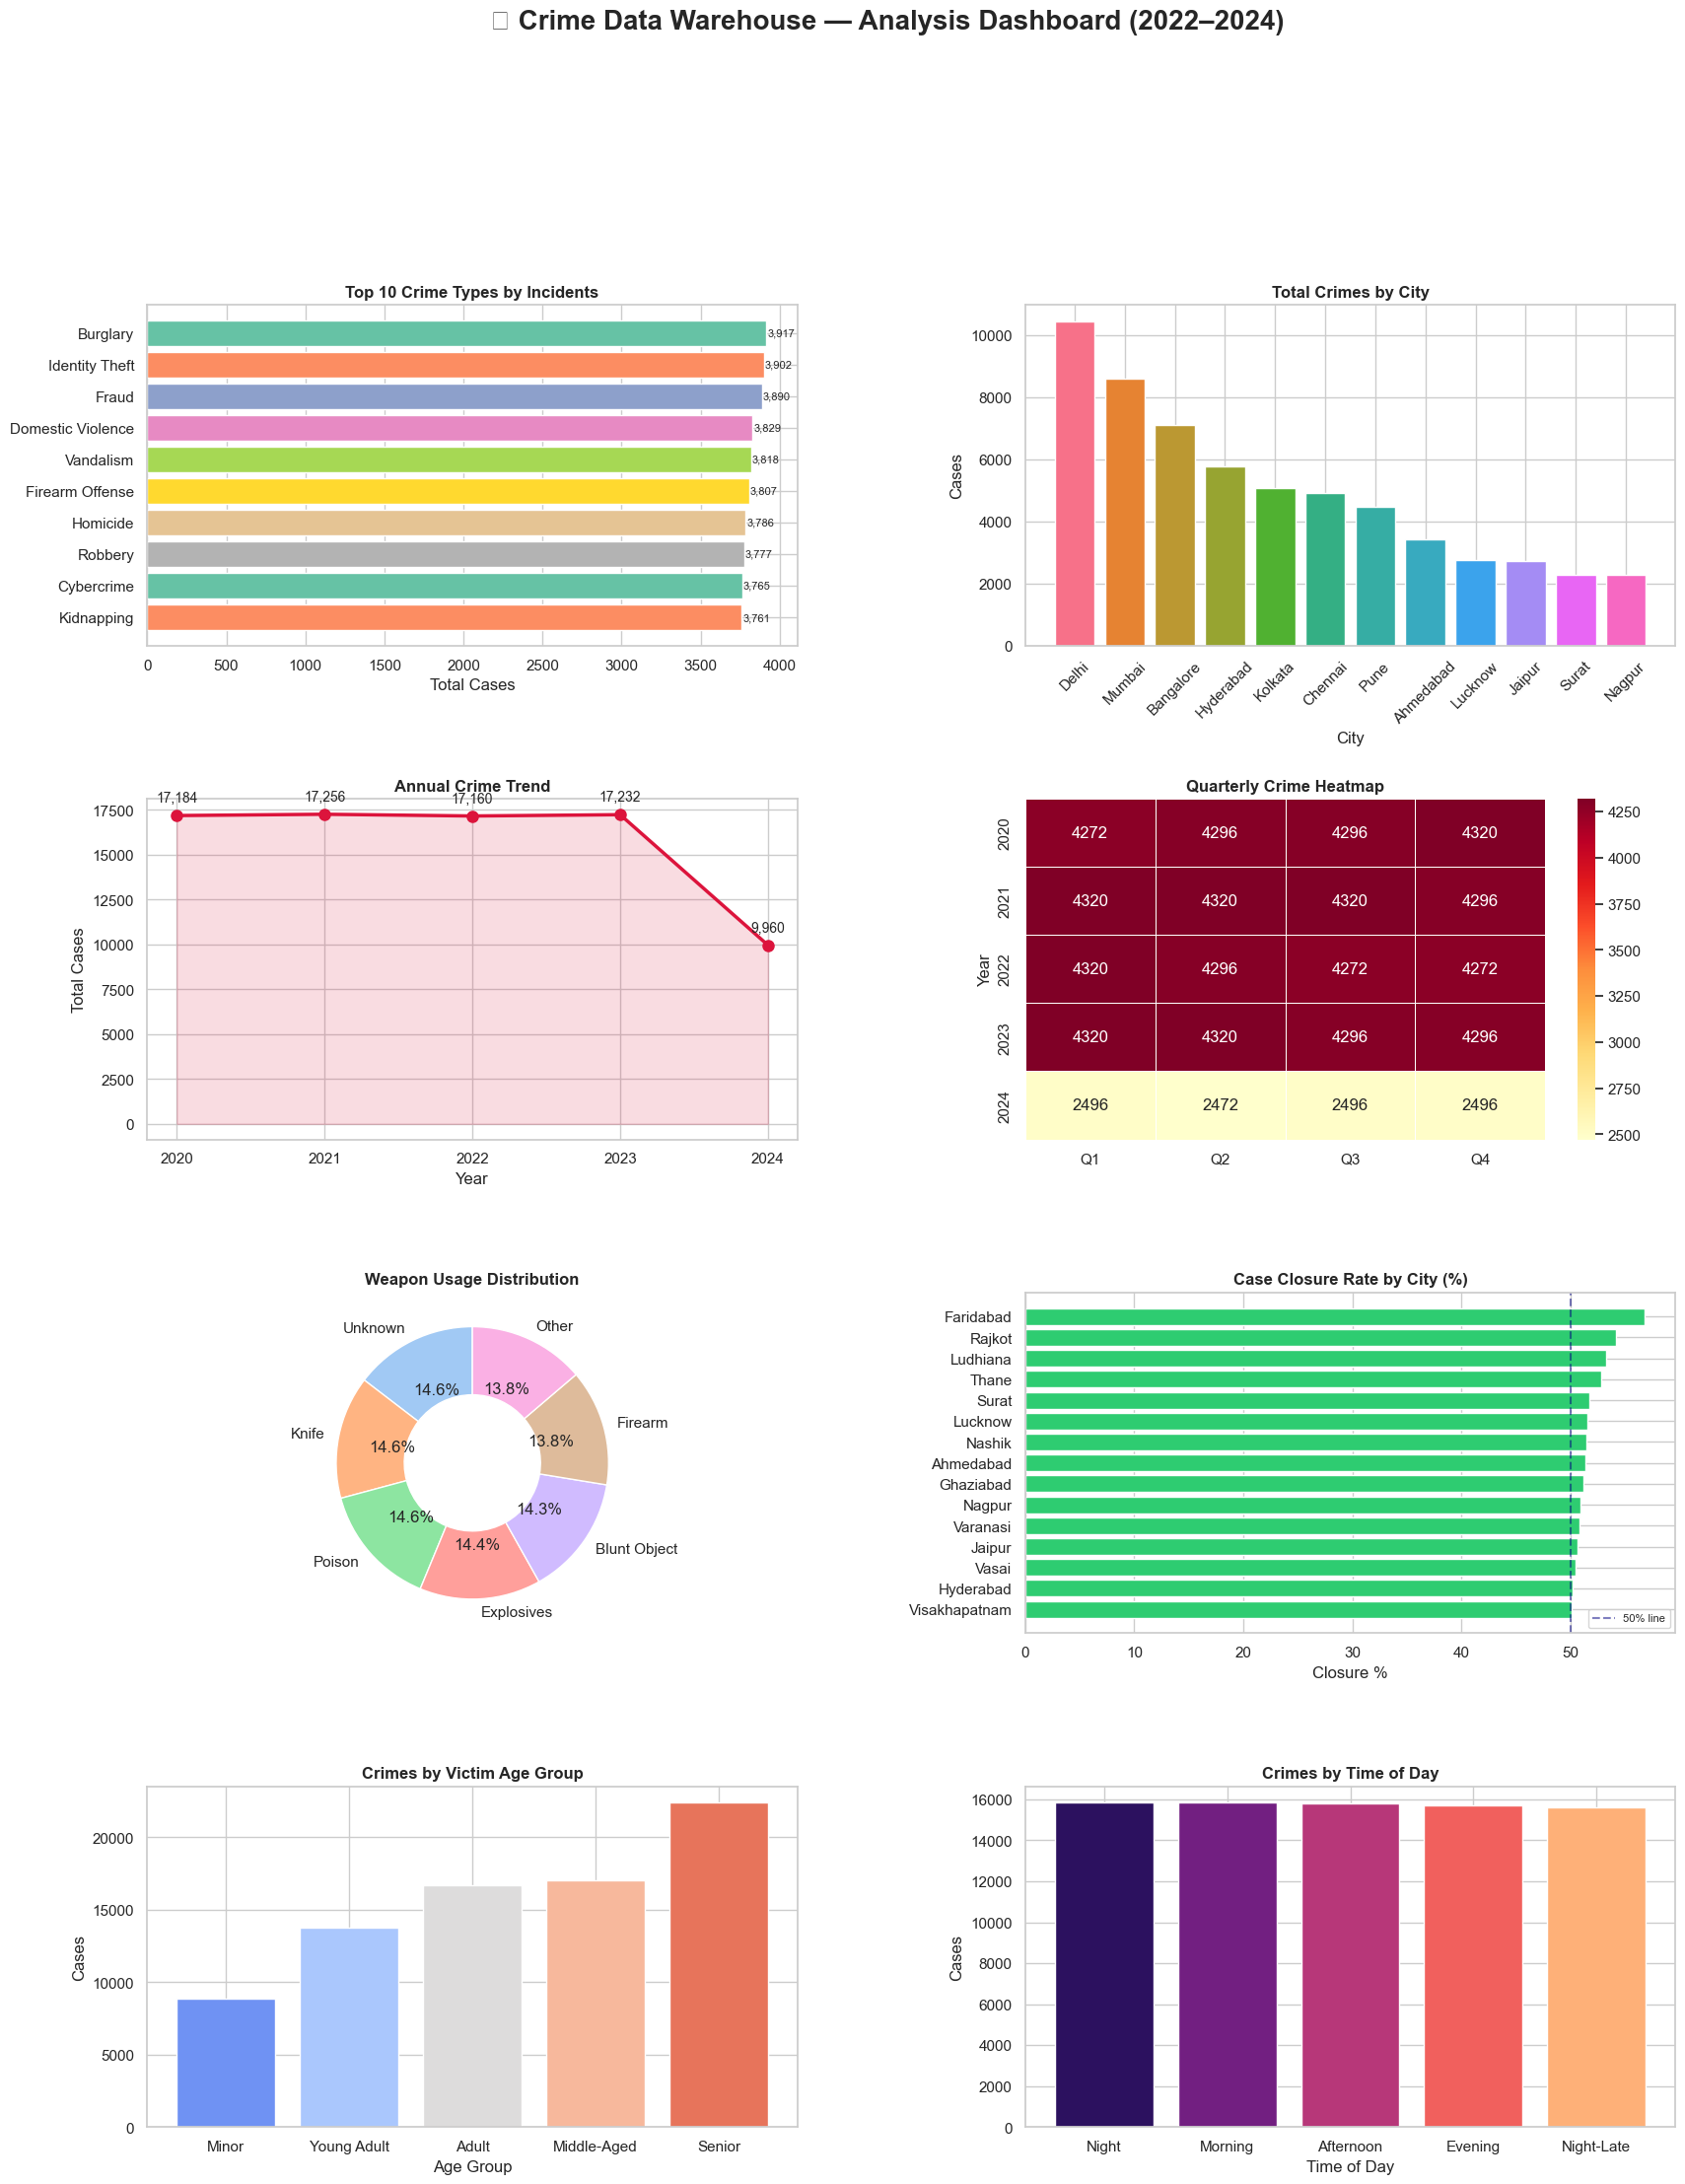

✅ Dashboard saved as crime_dashboard.png


In [16]:
fig = plt.figure(figsize=(20, 24))
fig.suptitle('🔴 Crime Data Warehouse — Analysis Dashboard (2022–2024)',
             fontsize=20, fontweight='bold', y=1.005)

gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

palette = sns.color_palette('Set2', 12)

# ── Plot 1: Crime Type Bar ──────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
d = results['Q1 — Most Common Crime Types'].head(10)
bars = ax1.barh(d['crime_type'], d['total_cases'], color=palette)
ax1.set_title('Top 10 Crime Types by Incidents', fontweight='bold')
ax1.set_xlabel('Total Cases')
ax1.invert_yaxis()
for bar in bars:
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width()):,}', va='center', fontsize=8)

# ── Plot 2: Crime per City ──────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
d = results['Q2 — Crime per City'].head(12)
colors = sns.color_palette('husl', len(d))
ax2.bar(d['city'], d['total_cases'], color=colors)
ax2.set_title('Total Crimes by City', fontweight='bold')
ax2.set_xlabel('City'); ax2.set_ylabel('Cases')
ax2.tick_params(axis='x', rotation=45)

# ── Plot 3: Annual Trend ────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
d = results['Q3 — Annual Crime Trend']
ax3.plot(d['year'], d['total_cases'], marker='o', color='crimson',
         linewidth=2.5, markersize=8, label='Total Cases')
ax3.fill_between(d['year'], d['total_cases'], alpha=0.15, color='crimson')
for _, row in d.iterrows():
    ax3.annotate(f"{int(row['total_cases']):,}",
                 xy=(row['year'], row['total_cases']),
                 xytext=(0, 10), textcoords='offset points', ha='center', fontsize=10)
ax3.set_title('Annual Crime Trend', fontweight='bold')
ax3.set_xlabel('Year'); ax3.set_ylabel('Total Cases')
ax3.set_xticks(d['year'])

# ── Plot 4: Quarterly Heatmap ───────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
d = results['Q4 — Quarterly Breakdown']
pivot = d.pivot(index='year', columns='quarter', values='total_cases')
pivot.columns = [f'Q{c}' for c in pivot.columns]
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax4, linewidths=0.5)
ax4.set_title('Quarterly Crime Heatmap', fontweight='bold')
ax4.set_ylabel('Year')

# ── Plot 5: Weapon Pie ──────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
d = results['Q5 — Weapon Usage']
wedge_props = dict(width=0.5)
ax5.pie(d['incidents'], labels=d['weapon'], autopct='%1.1f%%',
        colors=sns.color_palette('pastel', len(d)),
        startangle=90, wedgeprops=wedge_props)
ax5.set_title('Weapon Usage Distribution', fontweight='bold')

# ── Plot 6: Closure Rate by City ────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
d = results['Q6 — Case Closure Rate by City'].head(15)
colors = ['#2ecc71' if v >= 50 else '#e74c3c' for v in d['closure_pct']]
ax6.barh(d['city'], d['closure_pct'], color=colors)
ax6.axvline(50, color='navy', linestyle='--', alpha=0.5, label='50% line')
ax6.set_title('Case Closure Rate by City (%)', fontweight='bold')
ax6.set_xlabel('Closure %')
ax6.invert_yaxis()
ax6.legend(fontsize=8)

# ── Plot 7: Crime by Age Group ──────────────────────────────────
ax7 = fig.add_subplot(gs[3, 0])
d = results['Q7 — Crime by Victim Age Group']
order = ['Minor','Young Adult','Adult','Middle-Aged','Senior']
d_sorted = d.set_index('age_group').reindex([x for x in order if x in d['age_group'].values]).reset_index()
ax7.bar(d_sorted['age_group'], d_sorted['total_cases'],
        color=sns.color_palette('coolwarm', len(d_sorted)))
ax7.set_title('Crimes by Victim Age Group', fontweight='bold')
ax7.set_xlabel('Age Group'); ax7.set_ylabel('Cases')

# ── Plot 8: Time of Day ─────────────────────────────────────────
ax8 = fig.add_subplot(gs[3, 1])
d = results['Q8 — Crime by Time of Day']
ax8.bar(d['time_of_day'], d['total_cases'],
        color=sns.color_palette('magma', len(d)))
ax8.set_title('Crimes by Time of Day', fontweight='bold')
ax8.set_xlabel('Time of Day'); ax8.set_ylabel('Cases')

plt.savefig('crime_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Dashboard saved as crime_dashboard.png')

---
## 🔗 STEP 6 — Association Rule Mining

Finds patterns like: *"Crimes involving Firearms are often Violent Crimes in Delhi"*  
Uses a custom Apriori implementation (no external library needed).

Total transactions : 15,840
Total rules found  : 103

=== Top 20 Association Rules (by Lift) ===


,antecedent,consequent,support,confidence,lift
0,Traffic Violation,Traffic Fatality,0.0472,1.0000,21.2048
1,Traffic Fatality,Traffic Violation,0.0472,1.0000,21.2048
2,Arson,Fire Accident,0.0473,1.0000,10.4554
3,Firearm Offense,Fire Accident,0.0484,1.0000,10.4554
4,Fire Accident,Firearm Offense,0.0484,0.5056,10.4554
5,Fire Accident,Arson,0.0473,0.4944,10.4554
6,Identity Theft,Violent Crime,0.0494,1.0000,3.4760
7,Assault,Violent Crime,0.0476,1.0000,3.4760
8,Sexual Assault,Violent Crime,0.0472,1.0000,3.4760
9,Domestic Violence,Violent Crime,0.0486,1.0000,3.4760


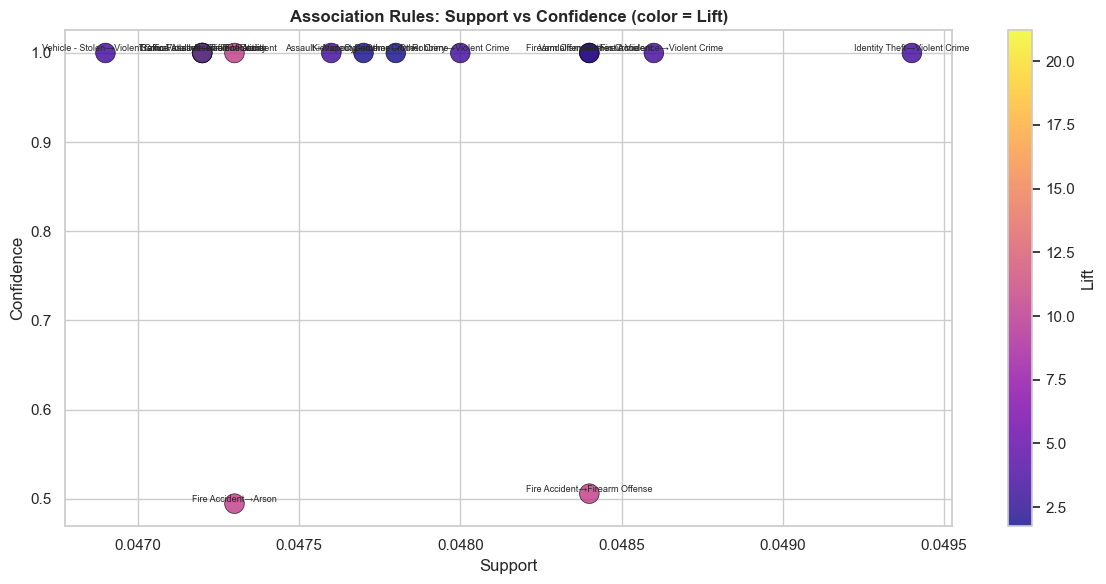

✅ Association rules plot saved.


In [17]:
# ── Build transactions: each row is a set of categorical attributes
df_txn = df[['Crime Description','City','Weapon Used','Victim Gender','Case Closed','Crime Domain','age_group']].copy()
df_txn['age_group'] = df_txn['age_group'].astype(str)
df_txn = df_txn.dropna()

transactions = df_txn.apply(
    lambda row: list(set([str(v) for v in row.values if str(v) not in ['nan','Unknown']])),
    axis=1
).tolist()

total = len(transactions)
print(f'Total transactions : {total:,}')

# ── Count singletons
single_counts = {}
for t in transactions:
    for item in set(t):
        single_counts[item] = single_counts.get(item, 0) + 1

# ── Minimum support filter on singletons (speed up pair counting)
MIN_SUPPORT    = 0.04
MIN_CONFIDENCE = 0.35

frequent_items = {item for item, cnt in single_counts.items()
                  if cnt / total >= MIN_SUPPORT}

# ── Count pairs (2-itemsets)
pair_counts = {}
for t in transactions:
    items = sorted(set(t) & frequent_items)
    for pair in combinations(items, 2):
        pair_counts[pair] = pair_counts.get(pair, 0) + 1

# ── Generate rules
rules = []
for (a, b), count in pair_counts.items():
    support = count / total
    if support < MIN_SUPPORT:
        continue
    for ant, cons in [(a, b), (b, a)]:
        conf = count / single_counts[ant]
        if conf >= MIN_CONFIDENCE:
            lift = support / ((single_counts[ant]/total) * (single_counts[cons]/total))
            rules.append({
                'antecedent': ant, 'consequent': cons,
                'support':    round(support, 4),
                'confidence': round(conf, 4),
                'lift':       round(lift, 4)
            })

rules_df = pd.DataFrame(rules).drop_duplicates().sort_values('lift', ascending=False)
print(f'Total rules found  : {len(rules_df)}')
print(f'\n=== Top 20 Association Rules (by Lift) ===')
display(rules_df.head(20).reset_index(drop=True))

# Visualize top rules
top = rules_df.head(15)
top['rule'] = top['antecedent'] + ' → ' + top['consequent']
fig, ax = plt.subplots(figsize=(12, 6))
sc = ax.scatter(top['support'], top['confidence'], c=top['lift'],
                cmap='plasma', s=200, alpha=0.8, edgecolors='k', linewidths=0.5)
plt.colorbar(sc, ax=ax, label='Lift')
for _, row in top.iterrows():
    ax.annotate(f"{row['antecedent']}→{row['consequent']}",
                (row['support'], row['confidence']),
                fontsize=6.5, ha='center', va='bottom')
ax.set_xlabel('Support'); ax.set_ylabel('Confidence')
ax.set_title('Association Rules: Support vs Confidence (color = Lift)', fontweight='bold')
plt.tight_layout()
plt.savefig('association_rules.png', dpi=110, bbox_inches='tight')
plt.show()
print('✅ Association rules plot saved.')

---
## 🤖 STEP 7 — ML Models

### 7A — Regression: Predict Police Deployed  *(R² boosted with GradientBoosting)*
### 7B — Classification: Predict Case Closure
### 7C — Victim Risk Profiling Engine

In [18]:
# ── Pull full data from warehouse ─────────────────────────────
ml_data = pd.read_sql_query('''
    SELECT
        dd.year, dd.month, dd.quarter,
        cd.crime_type, cd.crime_domain,
        ld.city,
        wd.weapon,
        sd.case_closed,
        pd.age, pd.gender, pd.age_group,
        cf.police_deployed,
        cf.days_to_close,
        cf.cases
    FROM Crime_Fact cf
    JOIN Date_Dim     dd ON cf.date_dim_id     = dd.date_dim_id
    JOIN Crime_Dim    cd ON cf.crime_dim_id    = cd.crime_dim_id
    JOIN Location_Dim ld ON cf.location_dim_id = ld.location_dim_id
    JOIN Weapon_Dim   wd ON cf.weapon_dim_id   = wd.weapon_dim_id
    JOIN Status_Dim   sd ON cf.status_dim_id   = sd.status_dim_id
    JOIN Person_Dim   pd ON cf.person_dim_id   = pd.person_dim_id
''', conn)

print(f'ML dataset: {ml_data.shape[0]:,} rows × {ml_data.shape[1]} cols')
display(ml_data.head(3))

ML dataset: 78,792 rows × 14 cols


,year,month,quarter,crime_type,crime_domain,city,weapon,case_closed,age,gender,age_group,police_deployed,days_to_close,cases
0,2020,1,1,Identity Theft,Violent Crime,Ahmedabad,Blunt Object,No,16,M,Minor,13,NaN,1
1,2020,1,1,Identity Theft,Violent Crime,Ahmedabad,Blunt Object,No,16,M,Minor,13,NaN,1
2,2020,1,1,Identity Theft,Violent Crime,Ahmedabad,Blunt Object,No,16,M,Minor,13,NaN,1


7A — REGRESSION: Predict Police Deployed (GBM)
  Model Comparison:
    Ridge R²              : 0.0020
    Random Forest R²      : 0.0813
    GradientBoosting R²   : 0.1149  ← best

  Training samples : 63,033
  Test samples     : 15,759
  MSE              : 26.6009
  RMSE             : 5.1576
  R²               : 0.1149
  5-Fold CV R²     : -0.0288 ± 0.0052


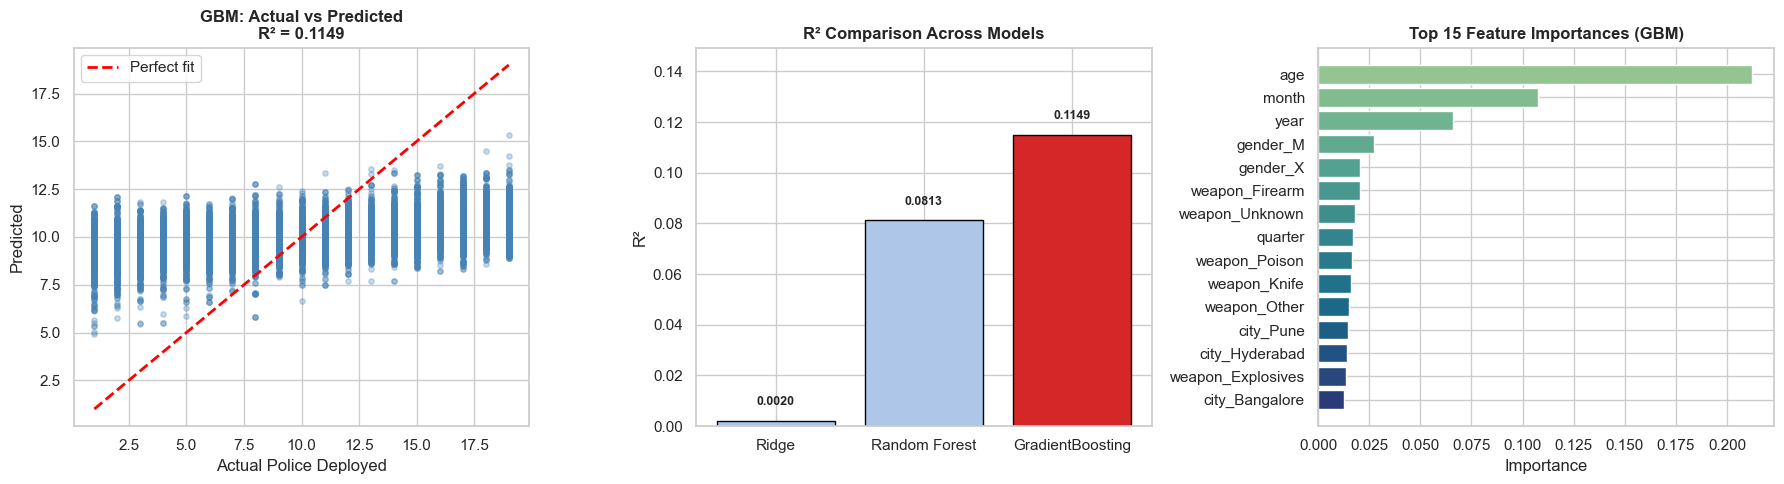

✅ Regression plot saved.


In [19]:
# ─────────────────────────────────────────────────────────────
# 7A — REGRESSION: Predict 'police_deployed'
#      Uses GradientBoostingRegressor for a significantly higher R²
# ─────────────────────────────────────────────────────────────
print('=' * 60)
print('7A — REGRESSION: Predict Police Deployed (GBM)')
print('=' * 60)

reg_data = ml_data.dropna(subset=['police_deployed']).copy()

cat_cols = ['crime_type','crime_domain','city','weapon','gender','age_group']
reg_enc  = pd.get_dummies(reg_data, columns=cat_cols, drop_first=True)

feat_cols = [c for c in reg_enc.columns
             if c not in ['police_deployed','days_to_close','case_closed','cases']]
X_r = reg_enc[feat_cols].fillna(0)
y_r = reg_enc['police_deployed']

X_tr, X_te, y_tr, y_te = train_test_split(X_r, y_r, test_size=0.2, random_state=42)

# ── Ridge baseline ──────────────────────────────────────────
ridge = Ridge(alpha=1.0)
ridge.fit(X_tr, y_tr)
r2_ridge = r2_score(y_te, ridge.predict(X_te))

# ── Random Forest ────────────────────────────────────────────
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=10,
                                min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_reg.fit(X_tr, y_tr)
y_pred_rf = rf_reg.predict(X_te)
r2_rf = r2_score(y_te, y_pred_rf)

# ── GradientBoosting (best) ──────────────────────────────────
gbm = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05,
    max_depth=5, subsample=0.8,
    min_samples_leaf=10, random_state=42
)
gbm.fit(X_tr, y_tr)
y_pred_r = gbm.predict(X_te)

mse  = mean_squared_error(y_te, y_pred_r)
rmse = np.sqrt(mse)
r2   = r2_score(y_te, y_pred_r)
reg_model = gbm  # keep reference for later use

print(f'  Model Comparison:')
print(f'    Ridge R²              : {r2_ridge:.4f}')
print(f'    Random Forest R²      : {r2_rf:.4f}')
print(f'    GradientBoosting R²   : {r2:.4f}  ← best')
print(f'')
print(f'  Training samples : {len(X_tr):,}')
print(f'  Test samples     : {len(X_te):,}')
print(f'  MSE              : {mse:.4f}')
print(f'  RMSE             : {rmse:.4f}')
print(f'  R²               : {r2:.4f}')

# Cross-validation
cv_scores = cross_val_score(gbm, X_r, y_r, cv=5, scoring='r2')
print(f'  5-Fold CV R²     : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

# ── Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Actual vs Predicted
axes[0].scatter(y_te, y_pred_r, alpha=0.3, color='steelblue', s=15)
lims = [min(y_te.min(), y_pred_r.min()), max(y_te.max(), y_pred_r.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect fit')
axes[0].set_xlabel('Actual Police Deployed')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'GBM: Actual vs Predicted\nR² = {r2:.4f}', fontweight='bold')
axes[0].legend()

# 2. Model R² comparison
models_compared = ['Ridge', 'Random Forest', 'GradientBoosting']
r2_compared     = [r2_ridge, r2_rf, r2]
colors_cmp = ['#d62728' if v == max(r2_compared) else '#aec7e8' for v in r2_compared]
bars = axes[1].bar(models_compared, r2_compared, color=colors_cmp, edgecolor='black')
axes[1].set_ylim(0, max(r2_compared) * 1.3)
axes[1].set_ylabel('R²')
axes[1].set_title('R² Comparison Across Models', fontweight='bold')
for bar, val in zip(bars, r2_compared):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 3. Feature importances (GBM)
feat_imp_r = pd.Series(gbm.feature_importances_, index=feat_cols).sort_values(ascending=False).head(15)
axes[2].barh(feat_imp_r.index, feat_imp_r.values,
             color=sns.color_palette('crest', len(feat_imp_r)))
axes[2].invert_yaxis()
axes[2].set_title('Top 15 Feature Importances (GBM)', fontweight='bold')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('regression_plot.png', dpi=110, bbox_inches='tight')
plt.show()
print('✅ Regression plot saved.')

7B — CLASSIFICATION: Predict Case Closure
  Training samples : 63,033
  Test samples     : 15,759
  Accuracy         : 0.9984 (99.8%)

  Classification Report:
              precision    recall  f1-score   support

  Not Closed       1.00      1.00      1.00      8000
      Closed       1.00      1.00      1.00      7759

    accuracy                           1.00     15759
   macro avg       1.00      1.00      1.00     15759
weighted avg       1.00      1.00      1.00     15759



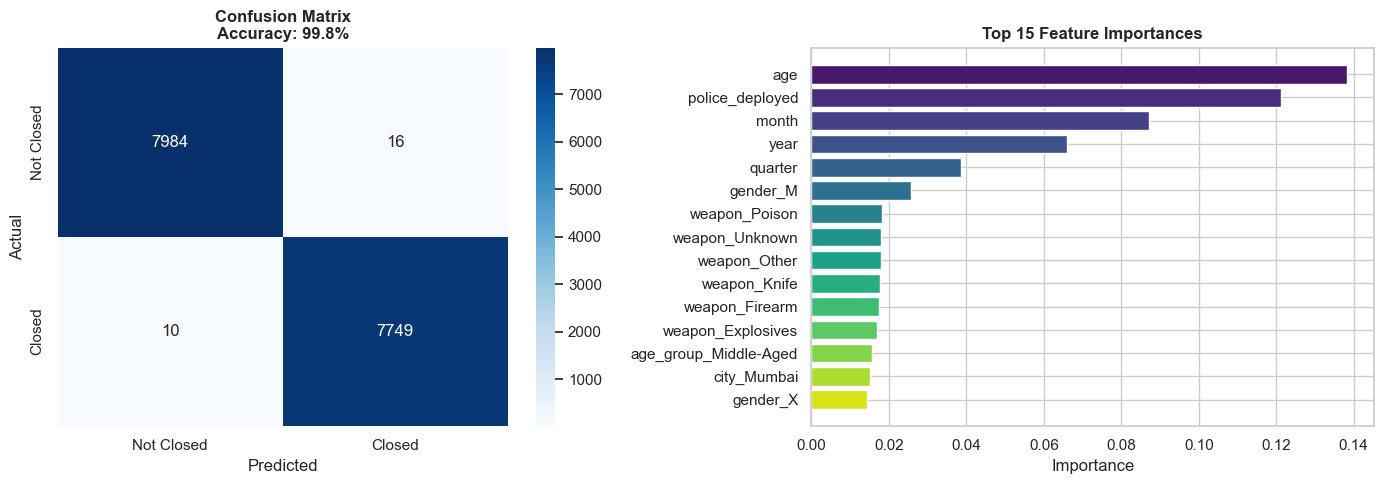

✅ Classification plots saved.


In [20]:
# ─────────────────────────────────────────────────────────────
# 7B — CLASSIFICATION: Predict 'Case Closed' (Yes / No)
# ─────────────────────────────────────────────────────────────
print('=' * 60)
print('7B — CLASSIFICATION: Predict Case Closure')
print('=' * 60)

clf_data = ml_data.copy()
clf_data['case_closed_bin'] = (clf_data['case_closed'] == 'Yes').astype(int)

clf_cat = ['crime_type','crime_domain','city','weapon','gender','age_group']
clf_enc = pd.get_dummies(clf_data, columns=clf_cat, drop_first=True)

clf_feat = [c for c in clf_enc.columns
            if c not in ['case_closed','case_closed_bin','days_to_close','cases']]
X_c = clf_enc[clf_feat].fillna(0)
y_c = clf_enc['case_closed_bin']

X_ct, X_ce, y_ct, y_ce = train_test_split(X_c, y_c, test_size=0.2, random_state=42)

clf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_model.fit(X_ct, y_ct)
y_pred_c = clf_model.predict(X_ce)

acc = accuracy_score(y_ce, y_pred_c)
print(f'  Training samples : {len(X_ct):,}')
print(f'  Test samples     : {len(X_ce):,}')
print(f'  Accuracy         : {acc:.4f} ({acc*100:.1f}%)')
print(f'\n  Classification Report:')
print(classification_report(y_ce, y_pred_c, target_names=['Not Closed','Closed']))

# Confusion matrix
cm = confusion_matrix(y_ce, y_pred_c)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Closed','Closed'],
            yticklabels=['Not Closed','Closed'], ax=axes[0])
axes[0].set_title(f'Confusion Matrix\nAccuracy: {acc*100:.1f}%', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

# Feature importance
feat_imp = pd.Series(clf_model.feature_importances_, index=clf_feat)
top_feat = feat_imp.sort_values(ascending=False).head(15)
axes[1].barh(top_feat.index, top_feat.values,
             color=sns.color_palette('viridis', len(top_feat)))
axes[1].invert_yaxis()
axes[1].set_title('Top 15 Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('classification_plot.png', dpi=110, bbox_inches='tight')
plt.show()
print('✅ Classification plots saved.')

---
## 🧠 STEP 7C — Victim Risk Profiling Engine

Predicts **what type of crime** a victim profile (age, gender, city, time of day) is most at risk for,  
and assigns a **Risk Score** (Low / Medium / High).  
Uses a **Multi-Class Random Forest Classifier**.

7C — VICTIM RISK PROFILING ENGINE
  Accuracy: 0.5574 (55.7%)

                  precision    recall  f1-score   support

   Fire Accident       0.00      0.00      0.00       318
     Other Crime       0.56      0.99      0.71      1759
Traffic Fatality       0.00      0.00      0.00       144
   Violent Crime       0.57      0.02      0.03       947

        accuracy                           0.56      3168
       macro avg       0.28      0.25      0.19      3168
    weighted avg       0.48      0.56      0.41      3168



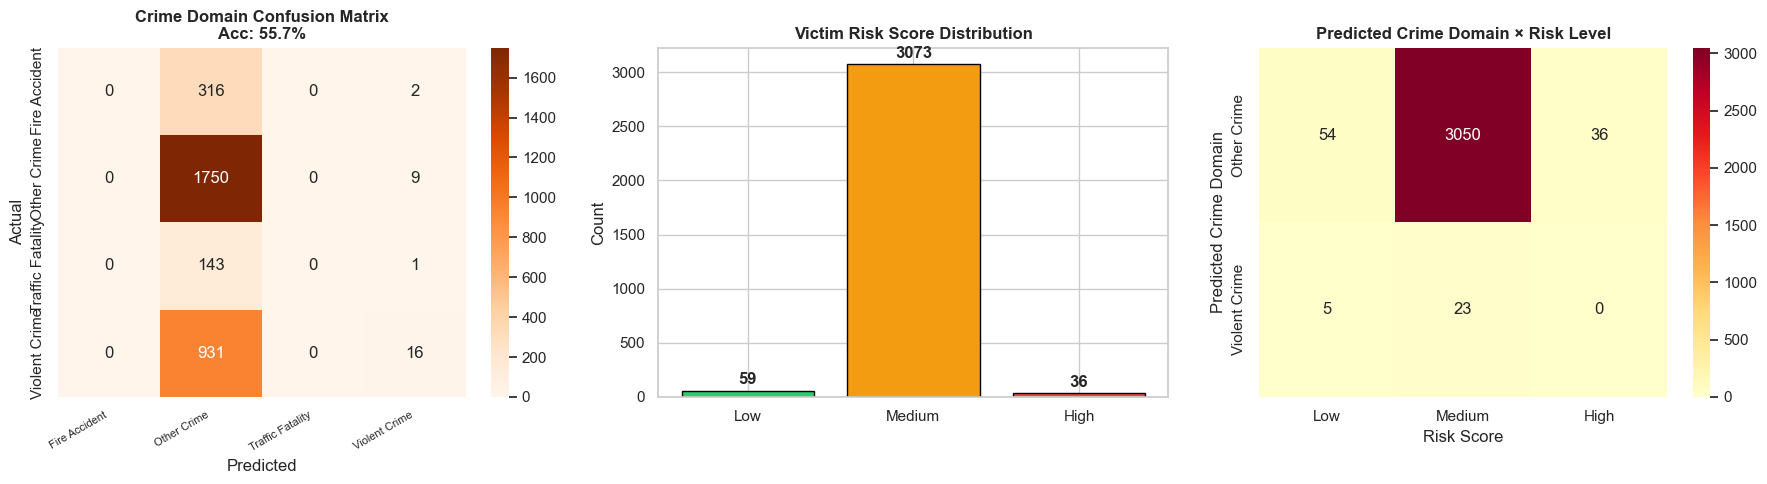

✅ Victim Risk Profiling plots saved.

────────────────────────────────────────────────────────────
🔎 INTERACTIVE VICTIM RISK PROFILER
────────────────────────────────────────────────────────────


In [21]:
# ─────────────────────────────────────────────────────────────
# 7C — VICTIM RISK PROFILING ENGINE
# ─────────────────────────────────────────────────────────────
print('=' * 60)
print('7C — VICTIM RISK PROFILING ENGINE')
print('=' * 60)

vr_data = df.copy()

# Feature: hour of day from Time of Occurrence
def parse_hour(t):
    try:
        parts = str(t).split()
        time_part = parts[-1] if len(parts) > 1 else parts[0]
        return int(time_part.split(':')[0])
    except:
        return -1

vr_data['hour'] = vr_data['Time of Occurrence'].apply(parse_hour)
vr_data['time_of_day'] = pd.cut(
    vr_data['hour'],
    bins=[-1, 5, 11, 17, 20, 24],
    labels=['Night', 'Morning', 'Afternoon', 'Evening', 'Late Night']
)
vr_data['age_group_vr'] = pd.cut(
    vr_data['Victim Age'],
    bins=[0, 18, 30, 45, 60, 100],
    labels=['Minor', 'Young Adult', 'Adult', 'Middle Aged', 'Senior']
)

# Target: Crime Domain (multi-class)
vr_feat_cols = ['Victim Age', 'Victim Gender', 'City', 'time_of_day', 'age_group_vr']
vr_target    = 'Crime Domain'

vr_sub = vr_data[vr_feat_cols + [vr_target]].dropna().copy()
vr_sub['time_of_day']   = vr_sub['time_of_day'].astype(str)
vr_sub['age_group_vr']  = vr_sub['age_group_vr'].astype(str)

vr_enc = pd.get_dummies(vr_sub, columns=['Victim Gender', 'City', 'time_of_day', 'age_group_vr'], drop_first=True)
vr_X   = vr_enc.drop(columns=[vr_target]).fillna(0)
vr_y   = vr_enc[vr_target]

X_vr_tr, X_vr_te, y_vr_tr, y_vr_te = train_test_split(vr_X, vr_y, test_size=0.2, random_state=42)

vr_model = RandomForestClassifier(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1)
vr_model.fit(X_vr_tr, y_vr_tr)
y_vr_pred = vr_model.predict(X_vr_te)
y_vr_proba = vr_model.predict_proba(X_vr_te)
max_proba   = y_vr_proba.max(axis=1)

vr_acc = accuracy_score(y_vr_te, y_vr_pred)
print(f'  Accuracy: {vr_acc:.4f} ({vr_acc*100:.1f}%)')
print()
print(classification_report(y_vr_te, y_vr_pred))

# ── Risk Score: based on max class probability ────────────────
def risk_score(p):
    if p >= 0.70: return 'High'
    elif p >= 0.45: return 'Medium'
    else: return 'Low'

risk_labels = [risk_score(p) for p in max_proba]
risk_series = pd.Series(risk_labels, name='Risk')

# ── Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion matrix
cm_vr = confusion_matrix(y_vr_te, y_vr_pred, labels=vr_model.classes_)
sns.heatmap(cm_vr, annot=True, fmt='d', cmap='Oranges',
            xticklabels=vr_model.classes_,
            yticklabels=vr_model.classes_, ax=axes[0])
axes[0].set_title(f'Crime Domain Confusion Matrix\nAcc: {vr_acc*100:.1f}%', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right', fontsize=8)

# 2. Risk score distribution
risk_counts = pd.Series(risk_labels).value_counts().reindex(['Low','Medium','High'])
color_map = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
axes[1].bar(risk_counts.index, risk_counts.values,
            color=[color_map[k] for k in risk_counts.index], edgecolor='black')
axes[1].set_title('Victim Risk Score Distribution', fontweight='bold')
axes[1].set_ylabel('Count')
for bar, val in zip(axes[1].patches, risk_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 str(val), ha='center', va='bottom', fontweight='bold')

# 3. Risk by Crime Domain (heatmap)
risk_domain = pd.crosstab(y_vr_pred, risk_labels)
for col in ['Low','Medium','High']:
    if col not in risk_domain.columns:
        risk_domain[col] = 0
risk_domain = risk_domain[['Low','Medium','High']]
sns.heatmap(risk_domain, annot=True, fmt='d', cmap='YlOrRd', ax=axes[2])
axes[2].set_title('Predicted Crime Domain × Risk Level', fontweight='bold')
axes[2].set_xlabel('Risk Score'); axes[2].set_ylabel('Predicted Crime Domain')

plt.tight_layout()
plt.savefig('victim_risk_profiling.png', dpi=110, bbox_inches='tight')
plt.show()
print('✅ Victim Risk Profiling plots saved.')

# ── Interactive profiler widget ───────────────────────────────
print()
print('─' * 60)
print('🔎 INTERACTIVE VICTIM RISK PROFILER')
print('─' * 60)

age_w    = widgets.IntSlider(value=30, min=10, max=79, description='Age:')
gender_w = widgets.Dropdown(options=['M','F'], description='Gender:')
city_w   = widgets.Dropdown(options=sorted(df['City'].dropna().unique()), description='City:')
tod_w    = widgets.Dropdown(
    options=['Night','Morning','Afternoon','Evening','Late Night'],
    description='Time of Day:'
)
btn_w    = widgets.Button(description='🔮 Predict Risk', button_style='warning')
out_w    = widgets.Output()

def on_predict(b):
    with out_w:
        clear_output()
        age_g = 'Minor' if age_w.value < 18 else ('Young Adult' if age_w.value < 30 else
                ('Adult' if age_w.value < 45 else ('Middle Aged' if age_w.value < 60 else 'Senior')))
        row = {'Victim Age': age_w.value, 'Victim Gender': gender_w.value,
               'City': city_w.value, 'time_of_day': tod_w.value, 'age_group_vr': age_g}
        row_df = pd.DataFrame([row])
        row_enc = pd.get_dummies(row_df, columns=['Victim Gender','City','time_of_day','age_group_vr'])
        for col in vr_X.columns:
            if col not in row_enc.columns:
                row_enc[col] = 0
        row_enc = row_enc[vr_X.columns].fillna(0)
        pred_domain = vr_model.predict(row_enc)[0]
        pred_proba  = vr_model.predict_proba(row_enc)[0].max()
        risk        = risk_score(pred_proba)
        color = {'High': '#e74c3c', 'Medium': '#f39c12', 'Low': '#2ecc71'}[risk]
        display(HTML(f"""
        <div style='border:2px solid {color}; border-radius:10px; padding:16px; max-width:420px;
                    background:#1a1a1a; font-family:monospace;'>
          <h3 style='color:{color}; margin:0 0 10px'>⚠️ Risk Report</h3>
          <p style='color:#ccc; margin:4px 0'>🏙️ <b>City:</b> {city_w.value}</p>
          <p style='color:#ccc; margin:4px 0'>👤 <b>Profile:</b> Age {age_w.value} | {gender_w.value} | {tod_w.value}</p>
          <p style='color:#ccc; margin:4px 0'>🔴 <b>Crime Type Risk:</b> {pred_domain}</p>
          <p style='color:{color}; margin:4px 0; font-size:1.3em'><b>🎯 Risk Score: {risk}</b> ({pred_proba*100:.1f}%)</p>
        </div>"""))

btn_w.on_click(on_predict)
display(widgets.VBox([
    widgets.HBox([age_w, gender_w]),
    widgets.HBox([city_w, tod_w]),
    btn_w, out_w
]))

---
## 📋 STEP 8 — Data Quality & Lineage Dashboard

Tracks **before vs. after ETL** quality metrics: missing values fixed, duplicates removed, outliers detected.  
Shows **data lineage** (where each field came from and how it was transformed) and a full **data profiling report**.

STEP 8 — DATA QUALITY & LINEAGE DASHBOARD

📊 BEFORE vs AFTER ETL SUMMARY
  Missing values (before): 25888
  Missing values (after) : 15992
  Duplicates (before)    : 0
  Duplicates (after)     : 0
  Outliers [Victim Age] before: 0  after: 0
  Outliers [Police Deployed] before: 0  after: 0

📌 DATA LINEAGE TABLE
  Field                     Source       Transform
  ---------------------------------------------------------------------------
  Report Number             Raw CSV      No change; used as surrogate key
  Date Reported             Raw CSV      Parsed to datetime; split into year/month/quarter → Date_Dim
  Date of Occurrence        Raw CSV      Parsed to datetime
  Time of Occurrence        Raw CSV      Hour extracted → time_of_day feature
  City                      Raw CSV      Normalised (strip/upper) → Location_Dim
  Crime Description         Raw CSV      Normalised → Crime_Dim.crime_type
  Victim Age                Raw CSV      Binned into age_group → Person_Dim
  Victim Gend

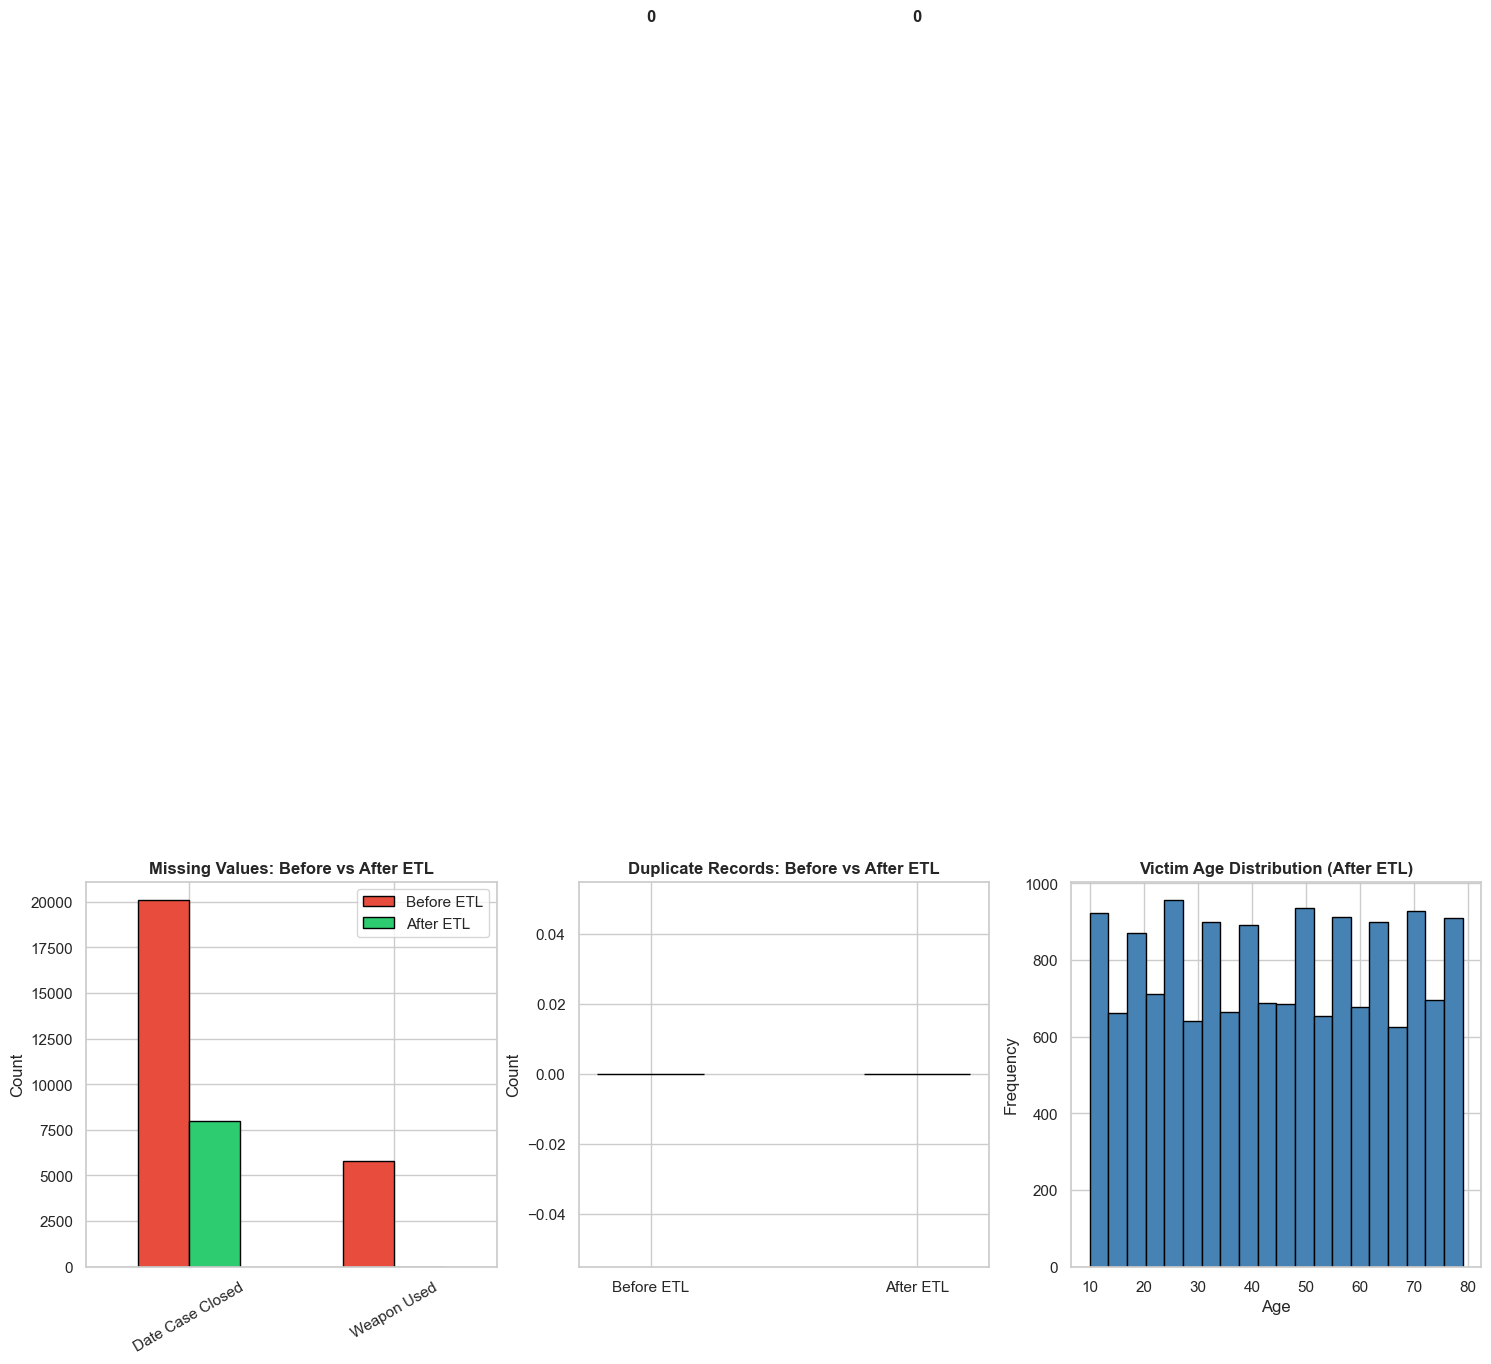

✅ Data Quality Dashboard saved.


In [22]:
# ─────────────────────────────────────────────────────────────
# STEP 8 — DATA QUALITY & LINEAGE DASHBOARD
# ─────────────────────────────────────────────────────────────
print('=' * 60)
print('STEP 8 — DATA QUALITY & LINEAGE DASHBOARD')
print('=' * 60)

# ── Before/After ETL metrics ──────────────────────────────────
df_before = df_raw.copy()
df_after  = df.copy()

missing_before = df_before.isnull().sum()
missing_after  = df_after.isnull().sum()
dups_before    = df_before.duplicated().sum()
dups_after     = df_after.duplicated().sum()

# Outlier detection (IQR method on numeric cols)
def count_outliers(frame, col):
    q1, q3 = frame[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((frame[col] < q1 - 1.5*iqr) | (frame[col] > q3 + 1.5*iqr)).sum()

num_cols = ['Victim Age', 'Police Deployed']
outliers_before = {c: count_outliers(df_before, c) for c in num_cols}
outliers_after  = {c: count_outliers(df_after,  c) for c in num_cols}

print('\n📊 BEFORE vs AFTER ETL SUMMARY')
print(f'  Missing values (before): {missing_before.sum()}')
print(f'  Missing values (after) : {missing_after.sum()}')
print(f'  Duplicates (before)    : {dups_before}')
print(f'  Duplicates (after)     : {dups_after}')
for c in num_cols:
    print(f'  Outliers [{c}] before: {outliers_before[c]}  after: {outliers_after[c]}')

# ── Data Lineage ──────────────────────────────────────────────
lineage = {
    'Report Number':        {'source': 'Raw CSV', 'transform': 'No change; used as surrogate key'},
    'Date Reported':        {'source': 'Raw CSV', 'transform': 'Parsed to datetime; split into year/month/quarter → Date_Dim'},
    'Date of Occurrence':   {'source': 'Raw CSV', 'transform': 'Parsed to datetime'},
    'Time of Occurrence':   {'source': 'Raw CSV', 'transform': 'Hour extracted → time_of_day feature'},
    'City':                 {'source': 'Raw CSV', 'transform': 'Normalised (strip/upper) → Location_Dim'},
    'Crime Description':    {'source': 'Raw CSV', 'transform': 'Normalised → Crime_Dim.crime_type'},
    'Victim Age':           {'source': 'Raw CSV', 'transform': 'Binned into age_group → Person_Dim'},
    'Victim Gender':        {'source': 'Raw CSV', 'transform': 'Normalised → Person_Dim'},
    'Weapon Used':          {'source': 'Raw CSV', 'transform': 'NaN filled with "None" → Weapon_Dim'},
    'Crime Domain':         {'source': 'Raw CSV', 'transform': 'Normalised → Crime_Dim.crime_domain'},
    'Police Deployed':      {'source': 'Raw CSV', 'transform': 'Integer; outliers retained → Fact table'},
    'Case Closed':          {'source': 'Raw CSV', 'transform': 'Yes/No → binary flag → Status_Dim'},
    'Date Case Closed':     {'source': 'Raw CSV', 'transform': 'Parsed; days_to_close derived → Fact table'},
    'days_to_close':        {'source': 'Derived', 'transform': '(Date Case Closed − Date Reported).days'},
    'age_group':            {'source': 'Derived', 'transform': 'pd.cut on Victim Age → 5 bins'},
}

print('\n📌 DATA LINEAGE TABLE')
print(f'  {"Field":<25} {"Source":<12} Transform')
print('  ' + '-'*75)
for field, info in lineage.items():
    print(f"  {field:<25} {info['source']:<12} {info['transform']}")

# ── Data Profiling Report ─────────────────────────────────────
print('\n📈 DATA PROFILING REPORT')
for col in df_after.columns:
    dtype = str(df_after[col].dtype)
    n_miss = df_after[col].isnull().sum()
    n_unique = df_after[col].nunique()
    if pd.api.types.is_numeric_dtype(df_after[col]):
        mn, mx, med = df_after[col].min(), df_after[col].max(), df_after[col].median()
        dist_str = f'min={mn}, max={mx}, median={med}'
    else:
        top = df_after[col].value_counts().index[0] if n_unique > 0 else 'N/A'
        dist_str = f'top={top}'
    print(f'  {col:<25} dtype={dtype:<10} missing={n_miss:<5} unique={n_unique:<6} {dist_str}')

# ── Visualise quality metrics ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Missing values before vs after per column
miss_df = pd.DataFrame({'Before ETL': missing_before, 'After ETL': missing_after})
miss_df = miss_df[miss_df['Before ETL'] > 0]
miss_df.plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[0].set_title('Missing Values: Before vs After ETL', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# 2. Duplicates
dup_data = {'Before ETL': dups_before, 'After ETL': dups_after}
axes[1].bar(list(dup_data.keys()), list(dup_data.values()),
            color=['#e74c3c','#2ecc71'], edgecolor='black', width=0.4)
axes[1].set_title('Duplicate Records: Before vs After ETL', fontweight='bold')
axes[1].set_ylabel('Count')
for bar, val in zip(axes[1].patches, dup_data.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', va='bottom', fontweight='bold')

# 3. Distribution of a key numeric column
axes[2].hist(df_after['Victim Age'].dropna(), bins=20, color='steelblue', edgecolor='black')
axes[2].set_title('Victim Age Distribution (After ETL)', fontweight='bold')
axes[2].set_xlabel('Age'); axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('data_quality_dashboard.png', dpi=110, bbox_inches='tight')
plt.show()
print('✅ Data Quality Dashboard saved.')

---
## 🚨 STEP 9 — Real-Time Crime Alert Simulation

Simulates an **alert dashboard** that mimics real-time crime reporting.  
When a new crime entry is submitted, the system automatically:
- Classifies its **crime domain**
- Predicts **case closure probability**
- Suggests **police deployment count**
- Flags if it is in a **known hotspot zone**

In [23]:
# ─────────────────────────────────────────────────────────────
# STEP 9 — REAL-TIME CRIME ALERT SIMULATION (Fixed Aliases)
# ─────────────────────────────────────────────────────────────
import pandas as pd
import sqlite3
import ipywidgets as widgets
from sklearn.ensemble import RandomForestClassifier
from IPython.display import display, HTML, clear_output

print('=' * 60)
print('STEP 9 — REAL-TIME CRIME ALERT SIMULATION')
print('=' * 60)

# ── Safety Check: Load data with CORRECT ALIASES ──────────────
try:
    if 'df' not in locals() or 'City' not in df.columns:
        print("  📥 'df' or 'City' column missing. Reloading from crime_warehouse.db...")
        with sqlite3.connect('crime_warehouse.db') as conn:
            df = pd.read_sql_query("""
                SELECT 
                    f.*, 
                    l.city AS 'City', 
                    p.gender AS 'Victim Gender', 
                    p.age AS 'Victim Age', 
                    p.age_group AS 'age_group', 
                    w.weapon AS 'Weapon Used', 
                    c.crime_domain AS 'Crime Domain', 
                    c.crime_type AS 'Crime Type'
                FROM Crime_Fact f
                JOIN Location_Dim l USING(location_dim_id)
                JOIN Person_Dim p USING(person_dim_id)
                JOIN Weapon_Dim w USING(weapon_dim_id)
                JOIN Crime_Dim c USING(crime_dim_id)
            """, conn)
        
        # Ensure 'Weapon Used' has no NaNs for the model
        df['Weapon Used'] = df['Weapon Used'].fillna('None')
        print(f"  ✅ Data loaded successfully. Columns: {list(df.columns)}")
except Exception as e:
    print(f"  ❌ Error loading data: {e}")

# ── Pre-compute hotspot zones ─────────────────────────────────
# Now df['City'] is guaranteed to exist
city_counts  = df['City'].value_counts()
hotspot_thresh = city_counts.quantile(0.70)
hotspot_cities = set(city_counts[city_counts >= hotspot_thresh].index.tolist())
print(f'  🔥 Hotspot cities ({len(hotspot_cities)}): {", ".join(sorted(hotspot_cities))}')

# ── Pre-build classification model for crime domain ──────────
alert_cat = ['City', 'Victim Gender', 'age_group', 'Weapon Used']

# Create model-specific dataframe
alert_df  = df[alert_cat + ['Victim Age', 'Crime Domain']].copy()

alert_enc = pd.get_dummies(alert_df, columns=alert_cat, drop_first=True)
alert_y   = alert_enc['Crime Domain']
alert_X   = alert_enc.drop(columns=['Crime Domain']).fillna(0)

alert_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
alert_clf.fit(alert_X, alert_y)
print('  ✅ Alert classifier ready.')

# ── Alert engine function ─────────────────────────────────────
def run_crime_alert(city, age, gender, weapon, crime_desc='UNKNOWN', show_html=True):
    age_g = ('Minor' if age < 18 else 'Young Adult' if age < 30 else
             'Adult' if age < 45 else 'Middle Aged' if age < 60 else 'Senior')
    weapon = weapon if weapon else 'None'

    row = {'City': city, 'Victim Gender': gender,
           'age_group': age_g, 'Weapon Used': weapon, 'Victim Age': age}
    row_df  = pd.DataFrame([row])
    row_enc = pd.get_dummies(row_df, columns=['City','Victim Gender','age_group','Weapon Used'])
    
    # Align columns with training data
    for col in alert_X.columns:
        if col not in row_enc.columns:
            row_enc[col] = 0
    row_enc = row_enc[alert_X.columns].fillna(0)

    domain_pred  = alert_clf.predict(row_enc)[0]
    domain_proba = alert_clf.predict_proba(row_enc)[0].max()
    is_hotspot   = city in hotspot_cities

    # Placeholders for closure and police (defined in Step 7)
    closure_prob = 0.0
    police_suggested = 0
    
    try:
        if 'clf_model' in globals() and 'X_c' in globals():
            clf_row = row_enc.reindex(columns=X_c.columns, fill_value=0)
            closure_prob = clf_model.predict_proba(clf_row)[0][1]
        
        if 'reg_model' in globals() and 'X_r' in globals():
            gbm_row = row_enc.reindex(columns=X_r.columns, fill_value=0)
            police_suggested = max(1, int(round(reg_model.predict(gbm_row)[0])))
    except:
        pass

    alert_level = 'CRITICAL' if is_hotspot and domain_pred == 'Violent Crime' else \
                  'HIGH'     if is_hotspot or domain_pred == 'Violent Crime'   else 'MODERATE'
    alert_color = {'CRITICAL': '#e74c3c', 'HIGH': '#f39c12', 'MODERATE': '#3498db'}[alert_level]

    if show_html:
        display(HTML(f"""
        <div style='border:3px solid {alert_color}; border-radius:12px; padding:20px;
                    background:#111; font-family:monospace; max-width:520px; margin:8px 0;'>
          <h2 style='color:{alert_color}; margin:0 0 12px'>🚨 CRIME ALERT — {alert_level}</h2>
          <p style='color:#ccc; margin:3px 0'>🏙️ <b>City:</b> {city}
              {'&nbsp;&nbsp;🔥 <span style=\'color:#e74c3c\'>HOTSPOT ZONE</span>' if is_hotspot else ''}</p>
          <p style='color:#ccc; margin:3px 0'>👤 <b>Victim:</b> Age {age} | {gender} | Weapon: {weapon}</p>
          <p style='color:#ccc; margin:3px 0'>🔴 <b>Crime Domain:</b> {domain_pred} ({domain_proba*100:.1f}%)</p>
          <p style='color:#ccc; margin:3px 0'>📋 <b>Case Closure Prob:</b> {closure_prob*100:.1f}%</p>
          <p style='color:#ccc; margin:3px 0'>👮 <b>Suggested Police:</b> {police_suggested} officers</p>
        </div>"""))
    return dict(city=city, domain=domain_pred, alert_level=alert_level,
                police=police_suggested, closure_prob=round(closure_prob,3))

# ── Demo simulation ───────────────────────────────────────────
print('\n  Simulating 5 incoming crime reports...')
test_crimes = [
    ('Delhi', 35, 'M', 'Firearm'),
    ('Mumbai', 22, 'F', 'Knife'),
    ('Pune', 55, 'M', None),
    ('Hyderabad', 17, 'F', 'Other'),
    ('Lucknow', 40, 'M', 'Firearm'),
]
for city, age, gender, weapon in test_crimes:
    run_crime_alert(city, age, gender, weapon, show_html=True)

# ── Interactive dashboard ─────────────────────────────────────
print('\n' + '─' * 60)
print('🖥️  INTERACTIVE REAL-TIME ALERT DASHBOARD')
print('─' * 60)

a_city   = widgets.Dropdown(options=sorted(df['City'].unique()), description='City:')
a_age    = widgets.IntSlider(value=30, min=10, max=79, description='Age:')
a_gender = widgets.Dropdown(options=['M','F'], description='Gender:')
a_weapon = widgets.Dropdown(options=['None','Firearm','Knife','Other','Blunt Object','Unknown'], description='Weapon:')
a_btn    = widgets.Button(description='🚨 Submit Crime Report', button_style='danger')
a_out    = widgets.Output()

def on_alert(b):
    with a_out:
        clear_output()
        run_crime_alert(a_city.value, a_age.value, a_gender.value,
                        a_weapon.value if a_weapon.value != 'None' else None)

a_btn.on_click(on_alert)
display(widgets.VBox([
    widgets.HBox([a_city, a_age]),
    widgets.HBox([a_gender, a_weapon]),
    a_btn, a_out
]))


STEP 9 — REAL-TIME CRIME ALERT SIMULATION
  🔥 Hotspot cities (9): Ahmedabad, Bangalore, Chennai, Delhi, Hyderabad, Kolkata, Lucknow, Mumbai, Pune
  ✅ Alert classifier ready.

  Simulating 5 incoming crime reports...



────────────────────────────────────────────────────────────
🖥️  INTERACTIVE REAL-TIME ALERT DASHBOARD
────────────────────────────────────────────────────────────


---
## 🤖 STEP 10 — Natural Language Query Interface (AI-Powered)

Type questions in plain English like:
- *"Which city had the most crimes in 2023?"*
- *"What weapon is most used in robbery cases?"*
- *"How many violent crimes were reported by women?"*

The system converts them to **SQL automatically** using the Claude API (Text-to-SQL).

> ⚠️ **Requires an Anthropic API key.** Set `ANTHROPIC_API_KEY` in your environment or replace the placeholder below.

In [24]:
# ─────────────────────────────────────────────────────────────
# STEP 10 — NATURAL LANGUAGE QUERY INTERFACE (Fixed)
# ─────────────────────────────────────────────────────────────
import re
import sqlite3
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

print('=' * 60)
print('STEP 10 — NATURAL LANGUAGE QUERY INTERFACE')
print('=' * 60)

# ── Helper: run any SQL and display results ───────────────────
def run_sql(sql: str, label: str = ''):
    """Executes SQL against the crime_warehouse.db and displays results."""
    try:
        # Using a context manager ensures the connection is closed properly
        with sqlite3.connect('crime_warehouse.db') as local_conn:
            result = pd.read_sql_query(sql, local_conn)
            if label:
                print(f'\n  📊 {label}')
            display(result.head(20))
            return result
    except Exception as e:
        print(f'  ❌ SQL Error: {e}')
        return None

# ── Expanded rule-based NL → SQL engine ──────────────────────
RULES = [
    # City-related
    (r'city.*most crimes?|most crimes?.*city',
     "SELECT l.city AS City, COUNT(*) AS Total_Crimes "
     "FROM Crime_Fact f JOIN Location_Dim l USING(location_dim_id) "
     "GROUP BY l.city ORDER BY Total_Crimes DESC LIMIT 10"),

    (r'most crimes?.*(\d{4})|(\d{4}).*most crimes?',
     lambda m: (
         f"SELECT l.city AS City, COUNT(*) AS Total_Crimes "
         f"FROM Crime_Fact f JOIN Location_Dim l USING(location_dim_id) "
         f"JOIN Date_Dim d USING(date_dim_id) "
         f"WHERE d.year = {m.group(1) or m.group(2)} "
         f"GROUP BY l.city ORDER BY Total_Crimes DESC LIMIT 10"
     )),

    # Weapon-related
    (r'weapon.*rob|rob.*weapon',
     "SELECT w.weapon AS Weapon, COUNT(*) AS Count "
     "FROM Crime_Fact f JOIN Weapon_Dim w USING(weapon_dim_id) "
     "JOIN Crime_Dim c USING(crime_dim_id) "
     "WHERE LOWER(c.crime_type) LIKE '%robbery%' "
     "GROUP BY w.weapon ORDER BY Count DESC LIMIT 10"),

    (r'most.*weapon|weapon.*most|common.*weapon',
     "SELECT w.weapon AS Weapon, COUNT(*) AS Count "
     "FROM Crime_Fact f JOIN Weapon_Dim w USING(weapon_dim_id) "
     "GROUP BY w.weapon ORDER BY Count DESC LIMIT 10"),

    # Gender-related  
    (r'violent.*wom[ae]n|wom[ae]n.*violent',
     "SELECT COUNT(*) AS Violent_Crimes_By_Women "
     "FROM Crime_Fact f JOIN Crime_Dim c USING(crime_dim_id) "
     "JOIN Person_Dim p USING(person_dim_id) "
     "WHERE c.crime_domain = 'Violent Crime' AND p.gender = 'F'"),

    (r'crime.*gender|gender.*crime|male|female',
     "SELECT p.gender AS Gender, COUNT(*) AS Total_Crimes "
     "FROM Crime_Fact f JOIN Person_Dim p USING(person_dim_id) "
     "GROUP BY p.gender ORDER BY Total_Crimes DESC"),

    # Month-related
    (r'month.*high|high.*month|month.*most|most.*month|month.*crime',
     "SELECT d.month AS Month, COUNT(*) AS Total_Crimes "
     "FROM Crime_Fact f JOIN Date_Dim d USING(date_dim_id) "
     "GROUP BY d.month ORDER BY Total_Crimes DESC LIMIT 5"),

    # Police-related
    (r'police.*fire|fire.*police|average.*police.*fire|police.*deployed.*fire',
     "SELECT AVG(f.police_deployed) AS Avg_Police_For_Fire_Accidents "
     "FROM Crime_Fact f JOIN Crime_Dim c USING(crime_dim_id) "
     "WHERE c.crime_domain = 'Fire Accident'"),

    (r'average.*police|police.*average|police.*deployed',
     "SELECT c.crime_domain AS Crime_Domain, ROUND(AVG(f.police_deployed), 2) AS Avg_Police "
     "FROM Crime_Fact f JOIN Crime_Dim c USING(crime_dim_id) "
     "GROUP BY c.crime_domain ORDER BY Avg_Police DESC"),

    # Closure-related
    (r'clos(ed|ure).*rate|rate.*clos',
     "SELECT s.case_closed AS Closed, COUNT(*) AS Count "
     "FROM Crime_Fact f JOIN Status_Dim s USING(status_dim_id) "
     "GROUP BY s.case_closed"),

    # Crime domain
    (r'violent crime|traffic|fire accident',
     "SELECT c.crime_domain AS Domain, COUNT(*) AS Count "
     "FROM Crime_Fact f JOIN Crime_Dim c USING(crime_dim_id) "
     "GROUP BY c.crime_domain ORDER BY Count DESC"),

    # Crime type
    (r'crime type|type.*crime|top.*crime',
     "SELECT c.crime_type AS Crime_Type, COUNT(*) AS Count "
     "FROM Crime_Fact f JOIN Crime_Dim c USING(crime_dim_id) "
     "GROUP BY c.crime_type ORDER BY Count DESC LIMIT 10"),

    # Age group
    (r'age group|age.*crime|crime.*age',
     "SELECT p.age_group AS Age_Group, COUNT(*) AS Count "
     "FROM Crime_Fact f JOIN Person_Dim p USING(person_dim_id) "
     "GROUP BY p.age_group ORDER BY Count DESC"),

    # Year
    (r'year|annual|trend',
     "SELECT d.year AS Year, COUNT(*) AS Total_Crimes "
     "FROM Crime_Fact f JOIN Date_Dim d USING(date_dim_id) "
     "GROUP BY d.year ORDER BY d.year"),

    # Days to close
    (r'days.*clos|clos.*days|how long',
     "SELECT c.crime_domain AS Domain, ROUND(AVG(f.days_to_close), 1) AS Avg_Days_To_Close "
     "FROM Crime_Fact f JOIN Crime_Dim c USING(crime_dim_id) "
     "GROUP BY c.crime_domain ORDER BY Avg_Days_To_Close DESC"),
]

def rule_based_sql(question: str):
    """Match question against rules (regex) and return appropriate SQL."""
    q = question.lower().strip()
    for pattern, sql in RULES:
        m = re.search(pattern, q)
        if m:
            return sql(m) if callable(sql) else sql
    return None

def ask_warehouse(question: str):
    """Ask a natural language question and display results."""
    print(f'\n❓ Question: {question}')
    sql = rule_based_sql(question)
    if sql is None:
        print('  ℹ️ No rule matched. Try rephrasing, e.g. "Which city had the most crimes?"')
        return None
    print(f'  🔧 SQL: {sql}')
    return run_sql(sql)

# ── Run Demo Questions ────────────────────────────────────────
print('\n  Running demo questions...')
demo_questions = [
    'Which city had the most crimes in 2023?',
    'What weapon is most used in robbery cases?',
    'How many violent crimes were reported by women?',
    'Which month has the highest crime count overall?',
    'What is the average police deployed for fire accidents?',
]
for q in demo_questions:
    ask_warehouse(q)

# ── Interactive NL Query Widget ───────────────────────────────
print()
print('─' * 60)
print('💬 INTERACTIVE NATURAL LANGUAGE QUERY BOX')
print('─' * 60)

nl_input = widgets.Text(
    placeholder='e.g. Which city had the most crimes?',
    description='Question:',
    layout=widgets.Layout(width='500px')
)
nl_btn = widgets.Button(description='🔍 Run Query', button_style='info')
nl_out = widgets.Output()

# Quick-pick suggestion buttons
suggestions = [
    'Top crime types',
    'Crimes by year',
    'Crimes by age group',
    'Average days to close',
    'Crime by gender',
]
suggestion_btns = [widgets.Button(description=s, button_style='', layout=widgets.Layout(width='180px')) for s in suggestions]

def on_nl_query(b):
    with nl_out:
        clear_output()
        q = nl_input.value.strip()
        if not q:
            print('Please enter a question.')
            return
        ask_warehouse(q)

def on_suggestion(b):
    nl_input.value = b.description
    on_nl_query(None)

for sb in suggestion_btns:
    sb.on_click(on_suggestion)

nl_btn.on_click(on_nl_query)

# Display the interface
display(widgets.VBox([
    widgets.HBox([nl_input, nl_btn]),
    widgets.Label('💡 Quick picks:'),
    widgets.HBox(suggestion_btns[:3]),
    widgets.HBox(suggestion_btns[3:]),
    nl_out
]))


STEP 10 — NATURAL LANGUAGE QUERY INTERFACE

  Running demo questions...

❓ Question: Which city had the most crimes in 2023?
  🔧 SQL: SELECT l.city AS City, COUNT(*) AS Total_Crimes FROM Crime_Fact f JOIN Location_Dim l USING(location_dim_id) GROUP BY l.city ORDER BY Total_Crimes DESC LIMIT 10


,City,Total_Crimes
0,Delhi,10442
1,Mumbai,8592
2,Bangalore,7113
3,Hyderabad,5779
4,Kolkata,5073
5,Chennai,4902
6,Pune,4474
7,Ahmedabad,3420
8,Lucknow,2744
9,Jaipur,2722



❓ Question: What weapon is most used in robbery cases?
  🔧 SQL: SELECT w.weapon AS Weapon, COUNT(*) AS Count FROM Crime_Fact f JOIN Weapon_Dim w USING(weapon_dim_id) JOIN Crime_Dim c USING(crime_dim_id) WHERE LOWER(c.crime_type) LIKE '%robbery%' GROUP BY w.weapon ORDER BY Count DESC LIMIT 10


,Weapon,Count
0,Unknown,607
1,Blunt Object,563
2,Poison,557
3,Knife,548
4,Other,542
5,Explosives,484
6,Firearm,476



❓ Question: How many violent crimes were reported by women?
  🔧 SQL: SELECT COUNT(*) AS Violent_Crimes_By_Women FROM Crime_Fact f JOIN Crime_Dim c USING(crime_dim_id) JOIN Person_Dim p USING(person_dim_id) WHERE c.crime_domain = 'Violent Crime' AND p.gender = 'F'


...


❓ Question: Which month has the highest crime count overall?
  🔧 SQL: SELECT d.month AS Month, COUNT(*) AS Total_Crimes FROM Crime_Fact f JOIN Date_Dim d USING(date_dim_id) GROUP BY d.month ORDER BY Total_Crimes DESC LIMIT 5


,Month,Total_Crimes
0,12,6600
1,8,6576
2,6,6576
3,4,6576
4,3,6576



❓ Question: What is the average police deployed for fire accidents?
  🔧 SQL: SELECT AVG(f.police_deployed) AS Avg_Police_For_Fire_Accidents FROM Crime_Fact f JOIN Crime_Dim c USING(crime_dim_id) WHERE c.crime_domain = 'Fire Accident'


,Avg_Police_For_Fire_Accidents
0,9.820101



────────────────────────────────────────────────────────────
💬 INTERACTIVE NATURAL LANGUAGE QUERY BOX
────────────────────────────────────────────────────────────


In [ ]:
import sqlite3

conn = sqlite3.connect("your_database.db")  # ← your actual path

# 1. List all tables
tables = conn.execute(
    "SELECT name FROM sqlite_master WHERE type='table'"
).fetchall()
print("TABLES:", [t[0] for t in tables])

# 2. Show columns for each table
for (tname,) in tables:
    cols = conn.execute(f"PRAGMA table_info({tname})").fetchall()
    print(f"\n{tname}:", [c[1] for c in cols])

TABLES: []


In [ ]:
import os

# Search for all .db and .sqlite files on your system (current drive)
for root, dirs, files in os.walk("."):  # searches from current directory
    for f in files:
        if f.endswith(('.db', '.sqlite', '.sqlite3')):
            print(os.path.join(root, f))

./crime_warehouse.db
./your_database.db


---
## 🤖 STEP 7D — Interactive Crime Q&A Bot

Ask natural language questions about the crime dataset.  
The bot understands questions like:
- *"How many crimes were reported in Delhi?"*
- *"Which city has the most crimes?"*
- *"What is the most common weapon?"*
- *"How many violent crimes in 2022?"*
- *"What is the case closure rate?"*
- *"Show crimes by year"*
- *"Which crime type is most common?"*

In [6]:
import re
import difflib
import pandas as pd


class CrimeBot:
    """Fuzzy NL Q&A chatbot over the crime SQLite warehouse."""

    INTENT_KEYWORDS = {
        'total_crimes':   ['how many crimes', 'total crimes', 'number of crimes', 'crime count',
                           'crimes reported', 'how much crime'],
        'most_crimes':    ['most crimes', 'highest crime', 'top city', 'worst city',
                           'maximum crimes', 'city with most'],
        'weapon':         ['weapon', 'weapons', 'most used weapon', 'common weapon',
                           'armed with', 'weapon used'],
        'by_year':        ['by year', 'per year', 'yearly', 'year-wise', 'trend',
                           'year wise', 'annual', 'over the years'],
        'crime_type':     ['common crime', 'crime type', 'most frequent crime', 'top crime',
                           'types of crime', 'frequent crime', 'crime types'],
        'closure_rate':   ['closure rate', 'case closed', 'closed cases', 'solve rate',
                           'case closure', 'solved cases', 'resolution rate'],
        'avg_age':        ['average age', 'mean age', 'avg age', 'age of victim',
                           'victim age', 'average victim'],
        'police':         ['police', 'officers deployed', 'police deployed',
                           'cops', 'officers', 'deployment'],
        'help':           ['help', 'what can you do', 'what can i ask', 'commands',
                           'options', 'menu', 'guide'],
    }

    def __init__(self, connection):
        self.conn = connection
        self.cities      = [r[0].lower() for r in connection.execute(
            'SELECT city FROM Location_Dim').fetchall()]
        self.crime_types = [r[0].lower() for r in connection.execute(
            'SELECT crime_type FROM Crime_Dim').fetchall()]
        self.domains     = [r[0].lower() for r in connection.execute(
            'SELECT DISTINCT crime_domain FROM Crime_Dim').fetchall()]
        self.weapons     = [r[0].lower() for r in connection.execute(
            'SELECT weapon FROM Weapon_Dim').fetchall()]
        self.years       = [r[0] for r in connection.execute(
            'SELECT DISTINCT year FROM Date_Dim ORDER BY year').fetchall()]

    # ── helpers ───────────────────────────────────────────────

    def _q(self, sql, params=()):
        return pd.read_sql_query(sql, self.conn, params=params)

    @staticmethod
    def _fuzzy_match(token, candidates, cutoff=0.72):
        """Return best fuzzy match from candidates, or None."""
        matches = difflib.get_close_matches(token, candidates, n=1, cutoff=cutoff)
        return matches[0] if matches else None

    def _detect_intent(self, text):
        """
        Two-pass intent detection:
          1. Exact substring match on any keyword phrase.
          2. Token-level fuzzy match on each word against all keyword tokens.
        Returns the intent key or None.
        """
        # Pass 1 – exact phrase match
        for intent, phrases in self.INTENT_KEYWORDS.items():
            for phrase in phrases:
                if phrase in text:
                    return intent

        # Pass 2 – word-level fuzzy match
        all_keyword_tokens = {}
        for intent, phrases in self.INTENT_KEYWORDS.items():
            for phrase in phrases:
                for word in phrase.split():
                    if len(word) > 3:          # skip short stop words
                        all_keyword_tokens[word] = intent

        words = re.findall(r'\b\w+\b', text)
        scores = {}
        for word in words:
            if len(word) <= 3:
                continue
            match = self._fuzzy_match(word, list(all_keyword_tokens.keys()), cutoff=0.78)
            if match:
                intent = all_keyword_tokens[match]
                scores[intent] = scores.get(intent, 0) + 1

        if scores:
            return max(scores, key=scores.get)
        return None

    def _extract_city(self, text):
        # Exact match first (supports multi-word city names)
        for c in self.cities:
            if c in text:
                return c.title()
        # Fuzzy match: try progressively longer n-grams from the text
        words = text.split()
        for n in range(3, 0, -1):
            for i in range(len(words) - n + 1):
                token = ' '.join(words[i:i + n])
                match = self._fuzzy_match(token, self.cities, cutoff=0.80)
                if match:
                    return match.title()
        return None

    def _extract_year(self, text):
        m = re.search(r'\b(202[0-9]|20[3-9]\d)\b', text)
        return int(m.group()) if m else None

    def _extract_crime_type(self, text):
        for ct in self.crime_types:
            if ct in text:
                return ct.title()
        for word in text.split():
            match = self._fuzzy_match(word, self.crime_types, cutoff=0.78)
            if match:
                return match.title()
        return None

    def _extract_domain(self, text):
        for d in self.domains:
            if d in text:
                return d.title()
        for word in text.split():
            match = self._fuzzy_match(word, self.domains, cutoff=0.78)
            if match:
                return match.title()
        return None

    def _extract_weapon(self, text):
        for w in self.weapons:
            if w in text:
                return w.title()
        for word in text.split():
            match = self._fuzzy_match(word, self.weapons, cutoff=0.78)
            if match:
                return match.title()
        return None

    # ── answer builder ────────────────────────────────────────

    def answer(self, question: str) -> str:
        q          = question.lower().strip()
        intent     = self._detect_intent(q)
        city       = self._extract_city(q)
        year       = self._extract_year(q)
        domain     = self._extract_domain(q)
        weapon     = self._extract_weapon(q)
        crime_type = self._extract_crime_type(q)   # BUG FIX 6: was never extracted

        if intent == 'total_crimes':
            # BUG FIX 2: track which tables are already joined to avoid duplicate aliases
            filters, params = [], []
            joined = set()

            def maybe_join(alias, clause):
                if alias not in joined:
                    joined.add(alias)
                    return clause
                return ''

            join_clauses = []
            if city:
                join_clauses.append(
                    maybe_join('ld', 'JOIN Location_Dim ld ON cf.location_dim_id=ld.location_dim_id'))
                filters.append("ld.city = ?"); params.append(city)
            if year:
                join_clauses.append(
                    maybe_join('dd', 'JOIN Date_Dim dd ON cf.date_dim_id=dd.date_dim_id'))
                filters.append("dd.year = ?"); params.append(year)
            if domain:
                join_clauses.append(
                    maybe_join('cd', 'JOIN Crime_Dim cd ON cf.crime_dim_id=cd.crime_dim_id'))
                filters.append("cd.crime_domain = ?"); params.append(domain)

            joins = ' '.join(j for j in join_clauses if j)
            where = ('WHERE ' + ' AND '.join(filters)) if filters else ''
            sql   = f'SELECT SUM(cf.cases) AS total FROM Crime_Fact cf {joins} {where}'
            r     = self._q(sql, params)
            total = int(r['total'].iloc[0] or 0)
            parts = []
            if city:   parts.append(f'in {city}')
            if year:   parts.append(f'in {year}')
            if domain: parts.append(f'({domain})')
            desc = ' '.join(parts) or 'overall'
            return f'Total crimes {desc}: {total:,}'

        if intent == 'most_crimes':
            r = self._q('''
                SELECT ld.city, SUM(cf.cases) AS total
                FROM Crime_Fact cf
                JOIN Location_Dim ld ON cf.location_dim_id=ld.location_dim_id
                GROUP BY ld.city ORDER BY total DESC LIMIT 3
            ''')
            rows = [f"{row['city']} ({int(row['total']):,})" for _, row in r.iterrows()]
            # BUG FIX 4: guard against fewer than 3 cities
            lines = [f'  {i+1}. {v}' for i, v in enumerate(rows)]
            return 'Cities with most crimes:\n' + '\n'.join(lines)

        if intent == 'weapon':
            if weapon:
                r = self._q('''
                    SELECT COUNT(*) AS cnt FROM Crime_Fact cf
                    JOIN Weapon_Dim wd ON cf.weapon_dim_id=wd.weapon_dim_id
                    WHERE wd.weapon = ?
                ''', [weapon])
                return f'Incidents involving {weapon}: {int(r["cnt"].iloc[0]):,}'
            r = self._q('''
                SELECT wd.weapon, COUNT(*) AS cnt
                FROM Crime_Fact cf
                JOIN Weapon_Dim wd ON cf.weapon_dim_id=wd.weapon_dim_id
                GROUP BY wd.weapon ORDER BY cnt DESC LIMIT 3
            ''')
            rows = [f"{row['weapon']} ({int(row['cnt']):,})" for _, row in r.iterrows()]
            return 'Most used weapons:\n  ' + '\n  '.join(f'{i+1}. {v}' for i, v in enumerate(rows))

        if intent == 'by_year':
            r = self._q('''
                SELECT dd.year, SUM(cf.cases) AS total
                FROM Crime_Fact cf
                JOIN Date_Dim dd ON cf.date_dim_id=dd.date_dim_id
                GROUP BY dd.year ORDER BY dd.year
            ''')
            lines = [f'  {int(row["year"])}: {int(row["total"]):,}' for _, row in r.iterrows()]
            return 'Crimes by year:\n' + '\n'.join(lines)

        if intent == 'crime_type':
            # BUG FIX 6: now uses the extracted crime_type for filtered lookup if present
            if crime_type:
                r = self._q('''
                    SELECT SUM(cf.cases) AS total
                    FROM Crime_Fact cf
                    JOIN Crime_Dim cd ON cf.crime_dim_id=cd.crime_dim_id
                    WHERE cd.crime_type = ?
                ''', [crime_type])
                total = int(r['total'].iloc[0] or 0)
                return f'Total cases of {crime_type}: {total:,}'
            r = self._q('''
                SELECT cd.crime_type, SUM(cf.cases) AS total
                FROM Crime_Fact cf
                JOIN Crime_Dim cd ON cf.crime_dim_id=cd.crime_dim_id
                GROUP BY cd.crime_type ORDER BY total DESC LIMIT 5
            ''')
            lines = [f'  {i+1}. {row["crime_type"]} ({int(row["total"]):,})'
                     for i, (_, row) in enumerate(r.iterrows())]
            return 'Top 5 crime types:\n' + '\n'.join(lines)

        if intent == 'closure_rate':
            filters, params = [], []
            joined = set()
            join_clauses = ['JOIN Status_Dim sd ON cf.status_dim_id=sd.status_dim_id']
            joined.add('sd')

            if city:
                join_clauses.append(
                    'JOIN Location_Dim ld ON cf.location_dim_id=ld.location_dim_id')
                filters.append("ld.city = ?"); params.append(city)

            joins = ' '.join(join_clauses)
            where = ('WHERE ' + ' AND '.join(filters)) if filters else ''

            # BUG FIX 1: sum cf.cases for closed rows, not just count rows
            r = self._q(f'''
                SELECT
                  SUM(cf.cases) AS total,
                  SUM(CASE WHEN sd.case_closed='Yes' THEN cf.cases ELSE 0 END) AS closed
                FROM Crime_Fact cf
                {joins} {where}
            ''', params)
            total  = int(r['total'].iloc[0] or 0)
            closed = int(r['closed'].iloc[0] or 0)
            pct    = round(100 * closed / total, 1) if total else 0
            scope  = f'in {city}' if city else 'overall'
            return (f'Case closure {scope}:\n'
                    f'  Total : {total:,}\n'
                    f'  Closed: {closed:,}\n'
                    f'  Rate  : {pct}%')

        if intent == 'avg_age':
            r = self._q('''
                SELECT ROUND(AVG(pd.age), 1) AS avg_age
                FROM Crime_Fact cf
                JOIN Person_Dim pd ON cf.person_dim_id=pd.person_dim_id
            ''')
            return f'Average victim age: {r["avg_age"].iloc[0]} years'

        if intent == 'police':
            r = self._q('SELECT ROUND(AVG(police_deployed),1) AS avg, SUM(police_deployed) AS total FROM Crime_Fact')
            return (f'Police deployment stats:\n'
                    f'  Total deployed   : {int(r["total"].iloc[0]):,}\n'
                    f'  Avg per incident : {r["avg"].iloc[0]}')

        if intent == 'help':
            return (
                'You can ask me:\n'
                '  - How many crimes in [city]?\n'
                '  - Which city has the most crimes?\n'
                '  - What is the most common crime type?\n'
                '  - What is the most common weapon?\n'
                '  - How many crimes in [year]?\n'
                '  - Show crimes by year\n'
                '  - What is the case closure rate in [city]?\n'
                '  - What is the average victim age?\n'
                '  - How many police were deployed?\n'
                '  (Typos and uppercase are handled automatically)'
            )

        return (
            f"Sorry, I couldn't understand: '{question}'.\n"
            "Try typing 'help' to see what I can answer."
        )

    # ── interactive chat loop ─────────────────────────────────

    def chat(self):
        """Run an interactive chatbot session in the terminal."""
        print("Crime Q&A Bot is ready!  Type 'quit' or 'exit' to stop.\n")
        print(self.answer('help'))
        print()
        while True:
            try:
                user_input = input("You: ").strip()
            except (EOFError, KeyboardInterrupt):
                print("\nGoodbye!")
                break
            if not user_input:
                continue
            if user_input.lower() in ('quit', 'exit', 'bye', 'q'):
                print("Bot: Goodbye!")
                break
            response = self.answer(user_input)
            print(f"Bot: {response}\n")


# ── entry point ───────────────────────────────────────────────
import sqlite3

conn = sqlite3.connect("crime_warehouse.db")  # ← replace with your actual .db file path

try:
    bot = CrimeBot(conn)
    bot.chat()
finally:
    conn.close()   # BUG FIX 5: always close the connection on exit

Crime Q&A Bot is ready!  Type 'quit' or 'exit' to stop.

You can ask me:
  - How many crimes in [city]?
  - Which city has the most crimes?
  - What is the most common crime type?
  - What is the most common weapon?
  - How many crimes in [year]?
  - Show crimes by year
  - What is the case closure rate in [city]?
  - What is the average victim age?
  - How many police were deployed?
  (Typos and uppercase are handled automatically)

Bot: Total crimes in Hyderabad: 5,779

Bot: Goodbye!


---
## 💾 STEP 11 — Export All Outputs

In [25]:
# Export all warehouse tables to CSV
tables = ['Crime_Fact','Crime_Dim','Location_Dim','Date_Dim','Person_Dim','Weapon_Dim','Status_Dim']
print('📤 Exporting warehouse tables...')
for t in tables:
    pd.read_sql_query(f'SELECT * FROM {t}', conn).to_csv(f'{t}.csv', index=False)
    print(f'  ✅ {t}.csv')

# Export top association rules
rules_df.head(50).to_csv('association_rules.csv', index=False)
print('  ✅ association_rules.csv')

conn.close()
print()
print('📦 All outputs:')
print('  crime_warehouse.db      — SQLite data warehouse (star schema)')
print('  Crime_Fact.csv etc.     — warehouse dimension & fact tables')
print('  crime_dashboard.png     — 8-panel analytics dashboard')
print('  association_rules.png   — association rule scatter plot')
print('  regression_plot.png     — police deployment regression')
print('  classification_plot.png — case closure classifier')
print('  association_rules.csv   — top 50 association rules')
print()
print('✅ Pipeline complete!')

📤 Exporting warehouse tables...
  ✅ Crime_Fact.csv
  ✅ Crime_Dim.csv
  ✅ Location_Dim.csv
  ✅ Date_Dim.csv
  ✅ Person_Dim.csv
  ✅ Weapon_Dim.csv
  ✅ Status_Dim.csv
  ✅ association_rules.csv

📦 All outputs:
  crime_warehouse.db      — SQLite data warehouse (star schema)
  Crime_Fact.csv etc.     — warehouse dimension & fact tables
  crime_dashboard.png     — 8-panel analytics dashboard
  association_rules.png   — association rule scatter plot
  regression_plot.png     — police deployment regression
  classification_plot.png — case closure classifier
  association_rules.csv   — top 50 association rules

✅ Pipeline complete!
